[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap08/cap08.EPs_aluno.ipynb)
[![](imagens/github-badge.png){width="19%"}](https://github.com/fzampirolli/pdi-vc)


## 💻 **Parte Prática com Exercícios de Programação**

A presente lista de exercícios de programação (EP) consolida as formulações teóricas apresentadas ao longo do Capítulo 8 — Correspondência de Características, Detecção de Objetos e Segmentação Clássica — por meio de uma trilha prática aplicada. Assim como no capítulo anterior, os EPs isolam as **grandezas intermediárias** de cada técnica — a distância entre descritores binários, os termos de uma imagem integral, a contagem de *inliers* de um modelo candidato, a sobreposição entre caixas delimitadoras e o rótulo de cada componente conectado — permitindo validar manualmente cada etapa do raciocínio sem depender do OpenCV nem de imagens externas.

O encadeamento dos exercícios reproduz o fluxo conceitual do capítulo: inicia-se com a **distância de Hamming**, coração da correspondência de descritores binários como o ORB; avança-se para a contagem de ***inliers*** que sustenta o **RANSAC** na estimação robusta de uma homografia; prossegue-se com a **imagem integral**, o truque computacional que torna o ***Haar Cascade*** viável em tempo real; aprofunda-se em **IoU e Supressão de Não-Máximos**, o pós-processamento comum a praticamente todo detector de objetos; e conclui-se com a **rotulação de componentes conectados**, a abordagem clássica — e suas limitações — para segmentar instâncias individuais em uma máscara binária.

### 🎯 Objetivo deste Caderno {.unnumbered}

O caderno permite desenvolver, validar, organizar e testar soluções de **Exercícios de Programação (EPs)** em ambientes interativos, como o Colab, com os mesmos casos de teste do Moodle, copiando para lá apenas na hora de registrar a nota oficial.


### *Download* {.unnumbered}

Baixe `morph.py` e `testsuite.py` executando a célula abaixo:


In [1]:
import os, sys, importlib, inspect, urllib.request

# URLs do repositório
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py", "testsuite.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph, testsuite
importlib.reload(morph); importlib.reload(testsuite)
from morph import mm
from testsuite import TestSuite

print(f"✅ Ambiente pronto. Morph: {morph.__version__} | TestSuite: {testsuite.__version__}")


✅ Ambiente pronto. Morph: 1.1.8 | TestSuite: 1.1.2


#### Executando os Testes {.unnumbered}
Para avaliar os testes, execute `TestSuite("EP08_01.extensão").run()` numa nova célula, trocando a extensão pela da linguagem usada (`.py`, `.java`, `.c`, `.cpp`, `.js` ou `.r`). O sistema baixa os casos de teste do GitHub, executa o programa e calcula a nota automaticamente.

Para testar código Python diretamente, sem salvar arquivo, use `run_code(codigo)` passando o código como *string* numa variável `codigo`:

```python
codigo = """
# ... seu código aqui ...
"""
TestSuite("EP08_01").run_code(codigo)
```

### 🛠️ Resumo dos Métodos do `morph.py` (Cap. 8) {.unnumbered}

A biblioteca `morph.py` disponibiliza funções para análise de componentes conexos, extração de contornos, métricas geométricas e anotações:

1. **Componentes e Contornos (`connectedComponents`, `findContours`)**
Rotulam regiões conexas e extraem os contornos de imagens binárias.
2. **Propriedades do Contorno (`contourArea`, `arcLength`, `convexHull`, `approxPolyDP`, `fitLine`)**
Calculam área, perímetro, fecho convexo, aproximação poligonal e ajuste de reta para um contorno.
3. **Geometria Envolvente (`boundingRect`, `minAreaRect`, `boxPoints`, `minEnclosingCircle`, `fitEllipse`)**
Determinam retângulos envolventes (alinhados ou orientados), elipses e o menor círculo delimitador.
4. **Extração e Persistência de Medidas (`measure`, `saveMeasures`)**
Extraem descritores geométricos dos objetos (área, circularidade, solidez, centroide) e exportam os dados para CSV, texto ou formato YOLO.
5. **Avaliação e Visualização (`IoU`, `verifyBoundBox`, `showBoundBox`)**
Calculam a intersecção sobre união (*Intersection over Union*), validam bounding boxes com gabaritos e desenham caixas delimitadoras anotadas sobre a imagem.

### EP08_01 🟢 Distância de Hamming e Correspondência de Descritores Binários

O ORB, usado no Projeto Prático 1 deste capítulo, descreve a vizinhança de cada ponto de interesse como uma sequência de bits — e, por isso, a comparação entre dois descritores não usa a distância euclidiana do k-NN do Capítulo 7, e sim a **distância de Hamming**: o número de posições em que os bits diferem. Antes de chamar `cv2.BFMatcher(cv2.NORM_HAMMING)`, você foi encarregado de implementar manualmente essa correspondência (*matching*) por força bruta — a mesma etapa que, executada internamente pelo OpenCV, precede a estimação robusta da homografia por RANSAC.

#### 📋 Diretrizes de Implementação

1. **Quantidades:** Ler os inteiros $N$ e $M$ — número de descritores extraídos da imagem A e da imagem B, respectivamente.
2. **Descritores de A:** Ler $N$ linhas, cada uma contendo um descritor binário (uma *string* de caracteres `0` e `1`, todos do mesmo comprimento).
3. **Descritores de B:** Ler $M$ linhas, no mesmo formato.
4. **Limiar:** Ler o inteiro $\tau$ — distância de Hamming máxima aceitável para considerar uma correspondência válida.
5. **Distância de Hamming:** Para dois descritores binários $a$ e $b$ de mesmo comprimento,
$$
d_H(a, b) = \sum_{k} \mathbb{1}[a_k \neq b_k],
$$
   ou seja, a contagem de posições em que os bits diferem.
6. **Correspondência por vizinho mais próximo:** Para cada descritor $a_i$ de A ($i$ na ordem de leitura, começando em $0$), calcule sua distância de Hamming a **todos** os descritores de B e encontre o de menor distância. Em caso de empate entre dois ou mais descritores de B com a mesma distância mínima, escolha o de **menor índice**.
7. **Filtragem pelo limiar:** Se a menor distância encontrada for $\le \tau$, a correspondência é válida; caso contrário, $a_i$ não possui correspondência.
8. **Saída:** Para cada $i$ de $0$ a $N-1$, na ordem de leitura, imprimir uma linha: `i j d` se houver correspondência válida (onde $j$ é o índice do descritor de B escolhido e $d$ sua distância), ou `i -1` caso contrário. Ao final, imprimir `Total correspondências válidas: X`.

#### 📌 Restrições Computacionais

* **Mesmo comprimento:** todos os descritores (de A e de B) têm exatamente o mesmo número de bits.
* **Força bruta:** compare cada descritor de A a **todos** os de B — não é necessário nenhum tipo de indexação ou estrutura de aceleração.
* **Desempate por menor índice em B**, e **nunca** por ordem de leitura de A (que já é natural, pois cada $a_i$ é tratado de forma independente).

#### 🧠 Fundamentação Teórica

| Elemento | Papel na correspondência ORB |
|---|---|
| Descritor binário (BRIEF) | Cada bit é o resultado de uma comparação de intensidade entre dois pixels da vizinhança |
| Distância de Hamming | Métrica de dissimetria entre *strings* binárias; muito mais rápida de calcular que a distância euclidiana (operação XOR + contagem de bits) |
| Vizinho mais próximo | Critério de correspondência: cada ponto de A é pareado ao ponto de B com descritor mais similar |
| Limiar $\tau$ | Filtra correspondências pouco confiáveis antes mesmo do RANSAC — mas, como discutido no capítulo, algumas correspondências incorretas ainda passam, exigindo a robustez do RANSAC |

#### 📦 Especificação de Entrada e Saída (VPL)

**Entrada:**

* Linha 1: Inteiros $N$ e $M$.
* Próximas $N$ linhas: um descritor binário por linha (*string* de `0`s e `1`s).
* Próximas $M$ linhas: um descritor binário por linha, no mesmo formato.
* Última linha: Inteiro $\tau$.

**Saída:**

* $N$ linhas, uma por descritor de A, no formato `i j d` ou `i -1`.
* Última linha: `Total correspondências válidas: X`.

#### 📌 Exemplos

| Entrada | Saída | Observação |
|---|---|---|
| 3 3<br>10101010<br>11110000<br>00001111<br>10101011<br>00001110<br>11111111<br>2 | 0 0 1<br>1 -1<br>2 1 1<br>Total correspondências válidas: 2 | O descritor `11110000` não encontra correspondência: seu vizinho mais próximo está a distância 4, acima do limiar $\tau=2$. |


In [2]:
#| label: fig-08-sim-ep0801
#| fig-cap: "Simulador EP08_01: Distância de Hamming entre Dois Descritores Binários"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0801" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-ep0801 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0801 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0801 button:hover { background: #e8dfcf; }
  .sim-ep0801_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0801_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
  .sim-ep0801_bit { width: 36px; height: 36px; display: flex; align-items: center; justify-content: center; border-radius: 6px; font-family: monospace; font-weight: 700; font-size: 14px; user-select: none; transition: all 0.15s ease; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP08_01: Distância de Hamming entre Descritores Binários</span>
  <span class="sim-ep0801_pill">Descritores de 8 Bits</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Painel Informativo de Instruções -->
  <div class="sim-ep0801_panel" style="margin-bottom:14px;">
    <div style="font-size:10.5px; color:#8a8371; font-weight:600; text-align:center;">
      Clique em qualquer bit do <b>Descritor B</b> para invertê-lo e observe a distância de Hamming mudar em tempo real.
    </div>
  </div>

  <!-- Grades dos Descritores -->
  <div class="sim-ep0801_panel" style="margin-bottom:14px; display:flex; flex-direction:column; gap:12px; align-items:center;">
    <div>
      <div style="font-size:10px; font-weight:700; color:#8a8371; text-transform:uppercase; margin-bottom:6px; text-align:center; letter-spacing:0.04em;">
        Descritor A (Fixo)
      </div>
      <div id="sim-ep0801_a" style="display:grid; grid-template-columns:repeat(8, 36px); gap:4px;"></div>
    </div>

    <div>
      <div style="font-size:10px; font-weight:700; color:#8a8371; text-transform:uppercase; margin-bottom:6px; text-align:center; letter-spacing:0.04em;">
        Descritor B (Clique para Inverter)
      </div>
      <div id="sim-ep0801_b" style="display:grid; grid-template-columns:repeat(8, 36px); gap:4px;"></div>
    </div>
  </div>

  <!-- Painel Informativo / Debug -->
  <div id="sim-ep0801_debug" class="sim-ep0801_panel" style="font-family:monospace; font-size:11px; color:#26241d; text-align:center;">
    &ndash;
  </div>

</div>
</div>

<script>
(function(){
  function initSim08Ep01(root){
    if (!root || root.dataset.sim08Ep01Init) return;
    root.dataset.sim08Ep01Init = "1";

    var A = [1, 0, 1, 0, 1, 0, 1, 0];
    var B = [1, 0, 1, 0, 1, 0, 1, 1];

    var aEl = root.querySelector('#sim-ep0801_a');
    var bEl = root.querySelector('#sim-ep0801_b');
    var dbg = root.querySelector('#sim-ep0801_debug');

    function estiloBit(destacado, interativo){
      var base = destacado 
        ? 'background:#fdecea; border:1px solid #f5b7b1; color:#c0392b;' 
        : 'background:#eafaf1; border:1px solid #a3e4d7; color:#04342C;';
      var cursor = interativo ? ' cursor:pointer;' : ' cursor:default;';
      return base + cursor;
    }

    function render(){
      aEl.innerHTML = ''; 
      bEl.innerHTML = '';
      var dist = 0;

      for (var k = 0; k < 8; k++){
        var diff = A[k] !== B[k];
        if (diff) dist++;

        var da = document.createElement('div');
        da.className = 'sim-ep0801_bit';
        da.style.cssText = estiloBit(diff, false);
        da.textContent = A[k];
        aEl.appendChild(da);

        var db = document.createElement('div');
        db.className = 'sim-ep0801_bit';
        db.style.cssText = estiloBit(diff, true);
        db.textContent = B[k];
        
        (function(idx){
          db.addEventListener('click', function(){
            B[idx] = 1 - B[idx];
            render();
          });
        })(k);

        bEl.appendChild(db);
      }

      if (dist === 0) {
        dbg.style.borderColor = '#a3e4d7';
        dbg.style.background  = '#eafaf1';
        dbg.style.color       = '#04342C';
      } else {
        dbg.style.borderColor = '#e4dcc8';
        dbg.style.background  = '#fafaf7';
        dbg.style.color       = '#26241d';
      }

      dbg.textContent = 'A = ' + A.join('') + '   B = ' + B.join('') + '   →   Distância de Hamming = ' + dist;
    }

    render();
  }

  function tryInitSim08Ep01(){
    var root = document.getElementById('sim-ep0801');
    if (root) initSim08Ep01(root); else setTimeout(tryInitSim08Ep01, 200);
  }
  tryInitSim08Ep01();
})();
</script>
""")

In [3]:
%%writefile EP08_01.py
# Código Python

Writing EP08_01.py


In [4]:
TestSuite("EP08_01.py").run()

### EP08_02 🟢 Homografia e RANSAC: A Votação por *Inliers*

O RANSAC, apresentado na seção "Modelagem Matemática: Homografia e RANSAC", repete um ciclo de três passos — sortear uma amostra mínima, estimar um modelo candidato, e contar quantas correspondências são consistentes com ele (os ***inliers***) — mantendo ao final o modelo mais votado. A etapa de estimação do modelo a partir de 4 pontos (passo 2) envolve álgebra linear que foge ao escopo deste EP; aqui, você recebe diretamente um conjunto de homografias **já candidatas** — como se cada uma tivesse sido estimada a partir de uma amostra aleatória diferente — e é encarregado de reproduzir exatamente o passo decisivo do algoritmo: **aplicar cada modelo a todas as correspondências e contar seus *inliers***, escolhendo o vencedor.

#### 📋 Diretrizes de Implementação

1. **Correspondências:** Ler o inteiro $N$ e, em seguida, $N$ linhas com quatro reais cada, $x\ y\ x'\ y'$ — um ponto da imagem A e seu correspondente (possivelmente incorreto) na imagem B, exatamente como produzido pela etapa de *matching* do EP08_01.
2. **Modelos candidatos:** Ler o inteiro $K$ (número de homografias candidatas) e o real $\varepsilon$ (limiar de erro de reprojeção). Em seguida, ler $K$ linhas, cada uma com nove reais $h_{11}\ h_{12}\ h_{13}\ h_{21}\ h_{22}\ h_{23}\ h_{31}\ h_{32}\ h_{33}$ — os elementos da matriz $H$ candidata, em ordem de leitura por linha (*row-major*).
3. **Reprojeção:** Para cada correspondência $(x,y,x',y')$ e cada modelo candidato $H_k$, calcular o ponto projetado
$$
\begin{bmatrix} \hat x \\ \hat y \\ \hat w \end{bmatrix} = H_k \begin{bmatrix} x \\ y \\ 1 \end{bmatrix},
\qquad
(\hat x / \hat w,\ \hat y / \hat w)\ \text{é o ponto projetado.}
$$
4. **Erro de reprojeção:** $e = \sqrt{(\hat x/\hat w - x')^2 + (\hat y /\hat w - y')^2}$.
5. **Contagem de *inliers*:** Uma correspondência é um *inlier* do modelo $H_k$ se $e \le \varepsilon$.
6. **Seleção do melhor modelo:** O modelo vencedor é o de maior número de *inliers*; em caso de empate, escolha o de **menor índice** $k$ (o primeiro encontrado durante o ciclo iterativo do RANSAC).
7. **Saída:** Para cada modelo $k$ de $0$ a $K-1$, na ordem de leitura, imprimir `Modelo k: I inliers`. Ao final, imprimir `Melhor modelo: k_best com I_best inliers`.

#### 📌 Restrições Computacionais

* **Comparação inclusiva:** um erro de reprojeção **exatamente igual** a $\varepsilon$ conta como *inlier* ($e \le \varepsilon$).
* **Sem estimação de $H$:** as matrizes já são fornecidas prontas — não é necessário (nem esperado) resolver nenhum sistema linear.
* **Empate resolvido pelo menor índice**, refletindo o comportamento natural de um algoritmo iterativo que percorre os modelos em ordem e só substitui o melhor encontrado até então quando um novo modelo o **supera estritamente**.

#### 🧠 Fundamentação Teórica

| Elemento | Papel no RANSAC |
|---|---|
| Amostra mínima (4 pares) | Suficiente para determinar os 8 graus de liberdade de uma homografia |
| Modelo candidato $H_k$ | Estimado a partir de uma amostra mínima; pode ser bom ou ruim, dependendo se a amostra continha *outliers* |
| Erro de reprojeção | Mede o quão bem o modelo "prevê" cada correspondência observada |
| *Inlier* vs. *outlier* | Correspondências consistentes com o modelo vencedor (*inliers*) vs. as demais, tipicamente correspondências incorretas do *matching* |
| Refinamento final | Na prática, após escolher o melhor modelo, o RANSAC o recalcula usando **apenas** seus *inliers* — passo não exigido neste EP |

#### 📦 Especificação de Entrada e Saída (VPL)

**Entrada:**

* Linha 1: Inteiro $N$.
* Próximas $N$ linhas: quatro reais $x\ y\ x'\ y'$.
* Próxima linha: Inteiro $K$ e real $\varepsilon$.
* Próximas $K$ linhas: nove reais (elementos de $H_k$, *row-major*).

**Saída:**

* $K$ linhas no formato `Modelo k: I inliers`.
* Última linha: `Melhor modelo: k_best com I_best inliers`.

#### 📌 Exemplos

| Entrada | Saída | Observação |
|---|---|---|
| 5<br>0 0 0 0<br>1 1 2 2<br>2 0 4 0<br>0 2 0 4<br>5 5 1 1<br>2 0.5<br>2 0 0 0 2 0 0 0 1<br>1 0 0 0 1 0 0 0 1 | Modelo 0: 4 inliers<br>Modelo 1: 1 inliers<br>Melhor modelo: 0 com 4 inliers | O Modelo 0 (escala ×2) explica corretamente 4 das 5 correspondências; a 5ª, $(5,5)\to(1,1)$, é um *outlier* que nenhum dos dois modelos explica bem. |


In [5]:
#| label: fig-08-sim-ep0802
#| fig-cap: "Simulador EP08_02: RANSAC — Votação por Inliers entre Modelos Candidatos"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0802" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-ep0802 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0802 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0802 button:hover { background: #e8dfcf; }
  #sim-ep0802 input[type=range] { width: 100%; accent-color: #26241d; cursor: pointer; height: 4px; }
  .sim-ep0802_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0802_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP08_02: RANSAC &mdash; Contagem de Inliers</span>
  <span class="sim-ep0802_pill">Modelo: Escala &times;2</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Painel de Controles -->
  <div class="sim-ep0808_panel sim-ep0802_panel" style="margin-bottom:14px;">
    <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:6px;">
      <label style="font-size:11px; font-weight:700; color:#5e5a4a;">
        Limiar (&epsilon;): <span id="sim-ep0802_vl" style="font-family:monospace; color:#26241d;">0.50</span>
      </label>
    </div>
    
    <input id="sim-ep0802_sl" type="range" min="0" max="13" step="0.25" value="0.5">
    
    <div style="font-size:10.5px; color:#8a8371; font-weight:600; margin-top:8px; text-align:center;">
      O modelo candidato mapeia (x,y) &rarr; (2x,2y). Ajuste o limiar &epsilon; e veja quais correspondências tornam-se inliers ou outliers.
    </div>
  </div>

  <!-- Cards de Pontos / Correspondências -->
  <div id="sim-ep0802_cards" style="display:grid; grid-template-columns: repeat(auto-fit, minmax(110px, 1fr)); gap:8px; margin-bottom:14px;"></div>

  <!-- Painel Informativo / Debug -->
  <div id="sim-ep0802_debug" class="sim-ep0802_panel" style="font-family:monospace; font-size:11px; color:#26241d; text-align:center;">
    &ndash;
  </div>

</div>
</div>

<script>
(function(){
  function initSim08Ep02(root){
    if (!root || root.dataset.sim08Ep02Init) return;
    root.dataset.sim08Ep02Init = "1";

    var pontos = [
      {x:0, y:0, xp:0, yp:0},
      {x:1, y:1, xp:2, yp:2},
      {x:2, y:0, xp:4, yp:0},
      {x:0, y:2, xp:0, yp:4},
      {x:5, y:5, xp:1, yp:1}
    ];

    var slEl  = root.querySelector('#sim-ep0802_sl');
    var vlEl  = root.querySelector('#sim-ep0802_vl');
    var cards = root.querySelector('#sim-ep0802_cards');
    var dbg   = root.querySelector('#sim-ep0802_debug');

    function render(){
      var eps = parseFloat(slEl.value);
      vlEl.textContent = eps.toFixed(2);
      cards.innerHTML = '';
      var inliers = 0;

      pontos.forEach(function(p){
        var px = 2 * p.x, py = 2 * p.y;
        var erro = Math.sqrt((px - p.xp) * (px - p.xp) + (py - p.yp) * (py - p.yp));
        var dentro = erro <= eps;
        if (dentro) inliers++;

        var div = document.createElement('div');
        div.style.cssText = 'text-align:center; border-radius:10px; padding:10px 6px; font-size:11px; transition:all 0.15s ease;' +
          (dentro 
            ? 'background:#eafaf1; border:1px solid #a3e4d7; color:#04342C;' 
            : 'background:#fdecea; border:1px solid #f5b7b1; color:#c0392b;');

        div.innerHTML = '<div style="font-weight:700; margin-bottom:4px;">(' + p.x + ',' + p.y + ') &rarr; (' + p.xp + ',' + p.yp + ')</div>' +
          '<div style="font-family:monospace; margin-bottom:4px; font-size:10px;">erro = ' + erro.toFixed(2) + '</div>' +
          '<div style="font-weight:700; font-size:10px;">' + (dentro ? 'INLIER' : 'outlier') + '</div>';

        cards.appendChild(div);
      });

      if (inliers > 0) {
        dbg.style.borderColor = '#a3e4d7';
        dbg.style.background  = '#eafaf1';
        dbg.style.color       = '#04342C';
      } else {
        dbg.style.borderColor = '#f5b7b1';
        dbg.style.background  = '#fdecea';
        dbg.style.color       = '#c0392b';
      }

      dbg.textContent = '\u03B5 = ' + eps.toFixed(2) + '  |  inliers = ' + inliers + ' de ' + pontos.length;
    }

    slEl.addEventListener('input', render);
    render();
  }

  function tryInitSim08Ep02(){
    var root = document.getElementById('sim-ep0802');
    if (root) initSim08Ep02(root); else setTimeout(tryInitSim08Ep02, 200);
  }
  tryInitSim08Ep02();
})();
</script>
""")

In [6]:
%%writefile EP08_02.py
# Código Python

Writing EP08_02.py


In [7]:
TestSuite("EP08_02.py").run()

### EP08_03 🟢 Imagem Integral: Somas Retangulares em Tempo Constante

Imagine uma câmera de segurança processando 30 quadros por segundo, e para cada quadro o sistema precisa varrer a imagem em dezenas de posições e escalas diferentes, testando em cada uma um conjunto de características retangulares para decidir "há um rosto aqui?". Se calcular a soma de intensidades de cada retângulo exigisse somar pixel a pixel, o sistema não teria a menor chance de avaliar em tempo real — o gargalo estaria justamente na parte mais repetida do algoritmo. É exatamente esse gargalo que a imagem integral elimina.

O Haar Cascade avalia milhares de características retangulares por janela, em múltiplas posições e escalas — algo inviável em tempo real se cada retângulo exigisse somar seus pixels um a um. A **imagem integral**, definida na seção sobre Haar Cascade, resolve esse problema: uma vez pré-computada, a soma de intensidades de **qualquer** região retangular é obtida com apenas quatro consultas e três operações aritméticas, independentemente do tamanho do retângulo.

Você foi encarregado de implementar essa estrutura do zero: primeiro, calcular a imagem integral a partir da imagem original; em seguida, respondê-la para consultas retangulares arbitrárias.

#### 📋 Diretrizes de Implementação

1. **Entrada:** Ler as dimensões $H \times W$ da imagem e seus $H \times W$ valores inteiros de intensidade.
2. **Imagem integral:** Calcular, para cada posição $(i,j)$ (indexação a partir de $0$, `[linha][coluna]`),
$$
II(i,j) = \sum_{i' \le i,\ j' \le j} I(i', j'),
$$
   ou seja, a soma de todos os pixels acima e à esquerda de $(i,j)$, incluindo a própria posição.
3. **Consultas:** Ler o inteiro $Q$ e, em seguida, $Q$ linhas, cada uma com quatro inteiros $x_1\ y_1\ x_2\ y_2$ — os cantos superior-esquerdo e inferior-direito de um retângulo, **ambos inclusivos**, com $0 \le x_1 \le x_2 < W$ e $0 \le y_1 \le y_2 < H$.
4. **Soma retangular em O(1):** Para cada consulta, calcular a soma de intensidades dentro do retângulo usando exclusivamente valores já presentes em $II$ (sem percorrer os pixels originais):
$$
S(x_1,y_1,x_2,y_2) = II(y_2,x_2) - II(y_2, x_1{-}1) - II(y_1{-}1, x_2) + II(y_1{-}1, x_1{-}1),
$$
   tratando qualquer termo com índice de linha ou coluna igual a $-1$ como $0$.
5. **Saída:** Primeiro, imprimir a imagem integral completa — $H$ linhas com $W$ inteiros cada. Em seguida, para cada consulta, imprimir um único inteiro: a soma da região correspondente.

#### 📌 Restrições Computacionais

* **Não recalcule por força bruta:** a resposta a cada consulta deve usar a fórmula de quatro termos sobre $II$, não uma soma direta dos pixels do retângulo (ainda que o resultado numérico seja o mesmo, o objetivo do exercício é justamente essa técnica).
* **Retângulos com coordenadas inclusivas:** $(x_1,y_1)$ e $(x_2,y_2)$ pertencem à região somada.
* **Tratamento de borda:** ao consultar $II$ com índice $-1$ (quando $x_1=0$ ou $y_1=0$), utilize o valor $0$.

#### 🧠 Fundamentação Teórica

| Elemento | Papel no Haar Cascade |
|---|---|
| Imagem integral $II$ | Pré-computada uma única vez por imagem, em tempo $O(HW)$ |
| Consulta em O(1) | Cada característica Haar (diferença entre somas de regiões retangulares) é avaliada com poucas operações, independentemente da área do retângulo |
| Escalabilidade | É essa constância que viabiliza avaliar milhares de características, em múltiplas posições e escalas, em tempo real |
| Princípio de inclusão-exclusão | Os quatro termos da fórmula somam a região desejada e subtraem exatamente as áreas contadas em excesso |

#### 📦 Especificação de Entrada e Saída (VPL)

**Entrada:**

* Linha 1: Inteiros $H$ e $W$.
* Próximas $H$ linhas: $W$ inteiros cada (imagem original).
* Próxima linha: Inteiro $Q$.
* Próximas $Q$ linhas: quatro inteiros $x_1\ y_1\ x_2\ y_2$.

**Saída:**

* $H$ linhas com $W$ inteiros cada (a imagem integral).
* $Q$ linhas, uma por consulta, com a soma da região correspondente.

#### 📌 Exemplos

| Entrada | Saída | Observação |
|---|---|---|
| 3 3<br>1 2 3<br>4 5 6<br>7 8 9<br>1<br>0 0 2 2 | 1 3 6<br>5 12 21<br>12 27 45<br>45 | A consulta cobre a imagem inteira; a soma coincide com $II(2,2)$ e com a soma de todos os 9 valores. |
| 3 3<br>1 2 3<br>4 5 6<br>7 8 9<br>2<br>1 1 2 2<br>0 0 1 1 | 1 3 6<br>5 12 21<br>12 27 45<br>28<br>12 | A primeira consulta usa os quatro termos da fórmula; a segunda coincide diretamente com $II(1,1)$, pois começa na origem. |


In [8]:
#| label: fig-08-sim-ep0803
#| fig-cap: "Simulador EP08_03: Soma Retangular em O(1) — Múltiplas Situações de Borda"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0803" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-ep0803 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0803 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0803 button:hover { background: #e8dfcf; }
  #sim-ep0803 input[type=range] { width: 100%; accent-color: #26241d; cursor: pointer; height: 4px; }
  .sim-ep0803_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0803_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP08_03: Soma Retangular com Imagem Integral</span>
  <span id="sim-ep0803_badge" class="sim-ep0803_pill">Interno</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Descrição e Botões de Preset -->
  <div class="sim-ep0803_panel" style="margin-bottom:14px;">
    <div style="font-size:10.5px; color:#8a8371; font-weight:600; text-align:center; margin-bottom:10px;">
      Escolha um retângulo (x<sub>1</sub>, y<sub>1</sub>) &ndash; (x<sub>2</sub>, y<sub>2</sub>). A imagem integral II inclui borda virtual (&minus;1) com zeros para validação sem exceções.
    </div>

    <div style="display:flex; gap:6px; justify-content:center; flex-wrap:wrap;">
      <button data-preset="0,0,3,3">Desde a Origem</button>
      <button data-preset="0,1,2,3">Borda Esquerda</button>
      <button data-preset="1,0,3,2">Borda Superior</button>
      <button data-preset="1,1,2,2">Totalmente Interno</button>
      <button data-preset="2,2,2,2">Pixel Único</button>
    </div>
  </div>

  <!-- Sliders de Seleção das Coordenadas -->
  <div class="sim-ep0803_panel" style="margin-bottom:14px;">
    <div style="display:grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap:12px;">
      
      <div>
        <div style="font-size:11px; font-weight:700; color:#5e5a4a; margin-bottom:4px;">
          Canto Superior-Esquerdo (x<sub>1</sub>, y<sub>1</sub>) = <span id="sim-ep0803_v_tl" style="font-family:monospace; color:#26241d;">(1,1)</span>
        </div>
        <div style="display:flex; justify-content:space-between; align-items:center; font-size:10px; color:#8a8371; font-weight:600;">x<sub>1</sub></div>
        <input id="sim-ep0803_x1" type="range" min="0" max="3" step="1" value="1">
        
        <div style="display:flex; justify-content:space-between; align-items:center; font-size:10px; color:#8a8371; font-weight:600; margin-top:4px;">y<sub>1</sub></div>
        <input id="sim-ep0803_y1" type="range" min="0" max="3" step="1" value="1">
      </div>

      <div>
        <div style="font-size:11px; font-weight:700; color:#5e5a4a; margin-bottom:4px;">
          Canto Inferior-Direito (x<sub>2</sub>, y<sub>2</sub>) = <span id="sim-ep0803_v_br" style="font-family:monospace; color:#26241d;">(2,2)</span>
        </div>
        <div style="display:flex; justify-content:space-between; align-items:center; font-size:10px; color:#8a8371; font-weight:600;">x<sub>2</sub></div>
        <input id="sim-ep0803_x2" type="range" min="0" max="3" step="1" value="2">
        
        <div style="display:flex; justify-content:space-between; align-items:center; font-size:10px; color:#8a8371; font-weight:600; margin-top:4px;">y<sub>2</sub></div>
        <input id="sim-ep0803_y2" type="range" min="0" max="3" step="1" value="2">
      </div>

    </div>
  </div>

  <!-- Grades das Matrizes -->
  <div style="display:flex; gap:20px; justify-content:center; flex-wrap:wrap; margin-bottom:14px;">
    <div class="sim-ep0803_panel" style="text-align:center;">
      <div style="font-size:10px; font-weight:700; color:#8a8371; text-transform:uppercase; margin-bottom:8px; letter-spacing:0.04em;">
        Imagem Original I (4&times;4)
      </div>
      <div id="sim-ep0803_gridI" style="display:grid; justify-content:center;"></div>
    </div>

    <div class="sim-ep0803_panel" style="text-align:center;">
      <div style="font-size:10px; font-weight:700; color:#8a8371; text-transform:uppercase; margin-bottom:8px; letter-spacing:0.04em;">
        Imagem Integral II (Com Borda Virtual &minus;1)
      </div>
      <div id="sim-ep0803_gridII" style="display:grid; justify-content:center;"></div>
    </div>
  </div>

  <!-- Legenda das Operações -->
  <div style="display:flex; gap:12px; justify-content:center; flex-wrap:wrap; margin-bottom:14px; font-size:10px; font-weight:700; color:#5e5a4a;">
    <span style="display:flex; align-items:center; gap:4px;"><span style="width:10px; height:10px; background:#2980b9; border-radius:2px; display:inline-block;"></span> + II(y<sub>2</sub>, x<sub>2</sub>)</span>
    <span style="display:flex; align-items:center; gap:4px;"><span style="width:10px; height:10px; background:#d35400; border-radius:2px; display:inline-block;"></span> &minus; II(y<sub>2</sub>, x<sub>1</sub>&minus;1)</span>
    <span style="display:flex; align-items:center; gap:4px;"><span style="width:10px; height:10px; background:#d35400; border-radius:2px; display:inline-block;"></span> &minus; II(y<sub>1</sub>&minus;1, x<sub>2</sub>)</span>
    <span style="display:flex; align-items:center; gap:4px;"><span style="width:10px; height:10px; background:#27ae60; border-radius:2px; display:inline-block;"></span> + II(y<sub>1</sub>&minus;1, x<sub>1</sub>&minus;1)</span>
  </div>

  <!-- Painéis Informativos / Resultados -->
  <div id="sim-ep0803_formula" class="sim-ep0803_panel" style="font-family:monospace; font-size:11px; color:#26241d; text-align:center; margin-bottom:8px;"></div>
  <div id="sim-ep0803_verify" class="sim-ep0803_panel" style="font-family:monospace; font-size:11px; color:#04342C; background:#eafaf1; border-color:#a3e4d7; text-align:center;"></div>

</div>
</div>

<script>
(function(){
  function initSim08Ep03(root){
    if (!root || root.dataset.sim08Ep03Init) return;
    root.dataset.sim08Ep03Init = "1";

    var I = [
      [2, 1, 3, 4],
      [5, 6, 1, 2],
      [3, 2, 4, 1],
      [1, 3, 2, 5]
    ];
    var N = 4;
    var II = [];
    for (var i = 0; i < N; i++){ II.push([0, 0, 0, 0]); }
    
    for (var i = 0; i < N; i++){
      for (var j = 0; j < N; j++){
        II[i][j] = I[i][j] +
          (i > 0 ? II[i - 1][j] : 0) + 
          (j > 0 ? II[i][j - 1] : 0) - 
          (i > 0 && j > 0 ? II[i - 1][j - 1] : 0);
      }
    }

    var x1El     = root.querySelector('#sim-ep0803_x1');
    var y1El     = root.querySelector('#sim-ep0803_y1');
    var x2El     = root.querySelector('#sim-ep0803_x2');
    var y2El     = root.querySelector('#sim-ep0803_y2');
    var vTl      = root.querySelector('#sim-ep0803_v_tl');
    var vBr      = root.querySelector('#sim-ep0803_v_br');
    var gridI    = root.querySelector('#sim-ep0803_gridI');
    var gridII   = root.querySelector('#sim-ep0803_gridII');
    var formulaEl= root.querySelector('#sim-ep0803_formula');
    var verifyEl = root.querySelector('#sim-ep0803_verify');
    var badge    = root.querySelector('#sim-ep0803_badge');

    var CELL = 34, HEAD = 20;

    function cellDiv(text, size, extraStyle){
      var d = document.createElement('div');
      d.style.cssText = 'display:flex; align-items:center; justify-content:center; font-family:monospace; font-size:' + size + 'px;' + extraStyle;
      d.textContent = text;
      return d;
    }

    function clampAndRender(changed){
      var x1 = +x1El.value, y1 = +y1El.value, x2 = +x2El.value, y2 = +y2El.value;
      if (changed === 'x1' && x1 > x2) x2El.value = x1;
      if (changed === 'x2' && x2 < x1) x1El.value = x2;
      if (changed === 'y1' && y1 > y2) y2El.value = y1;
      if (changed === 'y2' && y2 < y1) y1El.value = y2;
      render();
    }

    function render(){
      var x1 = +x1El.value, y1 = +y1El.value, x2 = +x2El.value, y2 = +y2El.value;
      vTl.textContent = '(' + x1 + ',' + y1 + ')';
      vBr.textContent = '(' + x2 + ',' + y2 + ')';

      var sit;
      if (x1 === x2 && y1 === y2) sit = 'Pixel Único';
      else if (x1 === 0 && y1 === 0) sit = 'Desde a Origem';
      else if (x1 === 0) sit = 'Borda Esquerda';
      else if (y1 === 0) sit = 'Borda Superior';
      else sit = 'Interno';

      badge.textContent = sit;

      // Grade I
      gridI.style.gridTemplateColumns = HEAD + 'px repeat(' + N + ',' + CELL + 'px)';
      gridI.style.gridTemplateRows = HEAD + 'px repeat(' + N + ',' + CELL + 'px)';
      gridI.innerHTML = '';
      gridI.appendChild(cellDiv('', 10, 'color:#8a8371;'));
      for (var c = 0; c < N; c++) gridI.appendChild(cellDiv(c, 10, 'color:#8a8371; font-weight:700;'));
      
      for (var r = 0; r < N; r++){
        gridI.appendChild(cellDiv(r, 10, 'color:#8a8371; font-weight:700;'));
        for (var c = 0; c < N; c++){
          var dentro = (r >= y1 && r <= y2 && c >= x1 && c <= x2);
          gridI.appendChild(cellDiv(I[r][c], 12, 'border-radius:4px; transition:all 0.15s ease;' +
            (dentro 
              ? 'background:#f1ead7; border:2px solid #26241d; font-weight:700; color:#26241d;'
              : 'background:#fafaf7; border:1px solid #e4dcc8; color:#8a8371;')));
        }
      }

      // Grade II (5x5 dados)
      var M = N + 1;
      gridII.style.gridTemplateColumns = HEAD + 'px repeat(' + M + ',' + CELL + 'px)';
      gridII.style.gridTemplateRows = HEAD + 'px repeat(' + M + ',' + CELL + 'px)';
      gridII.innerHTML = '';
      gridII.appendChild(cellDiv('', 10, 'color:#8a8371;'));
      for (var c2 = 0; c2 < M; c2++) gridII.appendChild(cellDiv(c2 - 1, 10, 'color:#8a8371; font-weight:700;'));

      var t1 = [y2 + 1, x2 + 1];
      var t2 = [y2 + 1, x1];
      var t3 = [y1, x2 + 1];
      var t4 = [y1, x1];

      function styleFor(r2, c2){
        var isVirtual = (r2 === 0 || c2 === 0);
        var base = isVirtual
          ? 'border-radius:4px; background:#fafaf7; border:1px dashed #e4dcc8; color:#8a8371;'
          : 'border-radius:4px; background:#fafaf7; border:1px solid #e4dcc8; color:#26241d;';
        
        function match(t, color, tcolor){
          if (r2 === t[0] && c2 === t[1]) {
            return 'border-radius:4px; font-weight:700; background:' + color + '; border:2px solid ' + tcolor + '; color:#ffffff;';
          }
          return null;
        }

        return match(t1, '#2980b9', '#1c5d85') || 
               match(t2, '#d35400', '#a04000') ||
               match(t3, '#d35400', '#a04000') || 
               match(t4, '#27ae60', '#1e8449') || base;
      }

      for (var r2 = 0; r2 < M; r2++){
        gridII.appendChild(cellDiv(r2 - 1, 10, 'color:#8a8371; font-weight:700;'));
        for (var c2 = 0; c2 < M; c2++){
          var val = (r2 === 0 || c2 === 0) ? 0 : II[r2 - 1][c2 - 1];
          gridII.appendChild(cellDiv(val, 12, styleFor(r2, c2)));
        }
      }

      function term(y, x){ return (y < 0 || x < 0) ? 0 : II[y][x]; }
      var a = term(y2, x2), b = term(y2, x1 - 1), c3 = term(y1 - 1, x2), d = term(y1 - 1, x1 - 1);
      var S = a - b - c3 + d;

      formulaEl.innerHTML =
        'S = II(' + y2 + ',' + x2 + ') &minus; II(' + y2 + ',' + (x1 - 1) + ') &minus; II(' + (y1 - 1) + ',' + x2 + ') + II(' + (y1 - 1) + ',' + (x1 - 1) + ')<br>' +
        'S = ' + a + ' &minus; ' + b + ' &minus; ' + c3 + ' + ' + d + ' = <b>' + S + '</b>';

      var direta = 0;
      for (var rr = y1; rr <= y2; rr++){
        for (var cc = x1; cc <= x2; cc++){
          direta += I[rr][cc];
        }
      }

      if (direta === S) {
        verifyEl.style.borderColor = '#a3e4d7';
        verifyEl.style.background  = '#eafaf1';
        verifyEl.style.color       = '#04342C';
      } else {
        verifyEl.style.borderColor = '#f5b7b1';
        verifyEl.style.background  = '#fdecea';
        verifyEl.style.color       = '#c0392b';
      }

      verifyEl.innerHTML = '&#10004; Verificação (Soma Direta dos Pixels) = ' + direta + (direta === S ? ' &rarr; Bate com S' : ' &rarr; Erro');
    }

    x1El.addEventListener('input', function(){ clampAndRender('x1'); });
    y1El.addEventListener('input', function(){ clampAndRender('y1'); });
    x2El.addEventListener('input', function(){ clampAndRender('x2'); });
    y2El.addEventListener('input', function(){ clampAndRender('y2'); });

    root.querySelectorAll('button[data-preset]').forEach(function(btn){
      btn.addEventListener('click', function(){
        var p = btn.getAttribute('data-preset').split(',').map(Number);
        x1El.value = p[0]; y1El.value = p[1]; x2El.value = p[2]; y2El.value = p[3];
        render();
      });
    });

    render();
  }

  function tryInitSim08Ep03(){
    var root = document.getElementById('sim-ep0803');
    if (root) initSim08Ep03(root); else setTimeout(tryInitSim08Ep03, 200);
  }
  tryInitSim08Ep03();
})();
</script>
""")

In [9]:
%%writefile EP08_03.py
# Código Python

Writing EP08_03.py


In [10]:
TestSuite("EP08_03.py").run()

### EP08_04 🟢 IoU e Supressão de Não-Máximos (NMS)

A figura desta seção mostrou o efeito da Supressão de Não-Máximos sobre um conjunto de caixas produzidas por um detector do tipo *sliding window*: múltiplas detecções redundantes por objeto foram reduzidas a uma única caixa por objeto. Você foi encarregado de reimplementar, byte a byte, as duas funções que produziram aquele resultado — `calcular_iou` e `supressao_nao_maximos` — para confirmar, com suas próprias mãos, exatamente os números que o capítulo apresentou.

#### 📋 Diretrizes de Implementação

1. **Entrada:** Ler o inteiro $N$ (número de caixas) e o real $\tau$ (limiar de IoU). Em seguida, ler $N$ linhas, cada uma com cinco reais $x_{min}\ y_{min}\ x_{max}\ y_{max}\ \text{score}$.
2. **Interseção sobre União:** Para duas caixas $A$ e $B$,
   $$
   \mathrm{IoU}(A,B) = \frac{\text{área}(A \cap B)}{\text{área}(A \cup B)},
   $$
   com área de interseção nula quando as caixas não se sobrepõem.
3. **Algoritmo de NMS** (exatamente como descrito no capítulo):
   
   a. Ordene as caixas por `score` decrescente (empates mantêm a ordem de leitura original).

   b. Selecione a caixa de maior pontuação entre as restantes; adicione-a à saída e remova-a da lista.

   c. Descarte, da lista restante, **todas** as caixas cujo IoU com a caixa selecionada seja **maior ou igual** a $\tau$ — apenas as caixas com $\mathrm{IoU} < \tau$ permanecem candidatas.
   
   d. Repita (b)–(c) até que a lista de restantes esteja vazia.

4. **Saída:** Para cada caixa mantida, na ordem em que foi selecionada, imprimir seu índice original (posição de leitura, a partir de $0$) e seu `score`, com 2 casas decimais. Ao final, imprimir `Total mantidas: X`.

#### 📌 Restrições Computacionais

* **Atenção ao sentido do limiar:** ao contrário do que se poderia supor, uma caixa é **suprimida** quando $\mathrm{IoU} \ge \tau$ (não apenas quando $\mathrm{IoU} > \tau$) — siga exatamente esse critério, o mesmo do código de referência do capítulo.
* **Índices originais:** a saída referencia a posição de leitura de cada caixa na entrada, não sua posição após a ordenação por `score`.
* **Área sem soma de 1 pixel:** use área $= (x_{max}-x_{min}) \times (y_{max}-y_{min})$, exatamente como no capítulo (sem o ajuste "+1" às vezes usado em outras convenções).

#### 🧠 Fundamentação Teórica

| Elemento | Papel no pós-processamento |
|---|---|
| IoU | Quantifica a sobreposição espacial entre duas caixas delimitadoras |
| *Sliding window* (Haar Cascade) | Produz tipicamente várias detecções sobrepostas para o mesmo objeto, em posições e escalas próximas |
| Limiar $\tau$ | Controla a agressividade da supressão: baixo demais funde objetos próximos; alto demais deixa passar redundâncias |
| Ordenação por `score` | Garante que, entre caixas redundantes, a de maior confiança sempre sobrevive |

#### 📦 Especificação de Entrada e Saída (VPL)

**Entrada:**

* Linha 1: Inteiro $N$ e real $\tau$.
* Próximas $N$ linhas: cinco reais $x_{min}\ y_{min}\ x_{max}\ y_{max}\ \text{score}$.

**Saída:**

* Uma linha por caixa mantida, na ordem de seleção: `índice score` (score com 2 casas decimais).
* Última linha: `Total mantidas: X`.

#### 📌 Exemplos

| Entrada | Saída | Observação |
|---|---|---|
| 5 0.4<br>50 50 150 150 0.90<br>60 55 155 145 0.75<br>58 60 160 150 0.60<br>300 300 400 420 0.95<br>310 305 395 415 0.70 | 3 0.95<br>0 0.90<br>Total mantidas: 2 | Exatamente o exemplo da figura do capítulo: 5 caixas redundantes (2 objetos) tornam-se 2 detecções finais. O IoU entre a 1ª e a 2ª caixas é $\approx 0{,}775$, bem acima de $\tau=0{,}4$. |


In [11]:
#| label: fig-08-sim-ep0804
#| fig-cap: "Simulador EP08_04: IoU e Supressão de Não-Máximos"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0804" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-ep0804 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0804 button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0804 button:hover { background: #e8dfcf; }
  #sim-ep0804 input[type=range] { width: 100%; accent-color: #26241d; cursor: pointer; height: 4px; }
  .sim-ep0804_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0804_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP08_04: IoU e Supressão de Não-Máximos (NMS)</span>
  <span class="sim-ep0804_pill">Supressão se IoU &ge; &tau;</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Painel de Controles -->
  <div class="sim-ep0804_panel" style="margin-bottom:14px;">
    <div style="display:grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap:12px;">
      
      <div>
        <div style="display:flex; justify-content:space-between; margin-bottom:4px;">
          <label style="font-size:11px; font-weight:700; color:#5e5a4a;">Deslocamento da Candidata (dx)</label>
          <span id="sim-ep0804_dx_v" style="font-family:monospace; font-weight:700; color:#26241d;">3</span>
        </div>
        <input id="sim-ep0804_dx" type="range" min="0" max="10" step="1" value="3">
      </div>

      <div>
        <div style="display:flex; justify-content:space-between; margin-bottom:4px;">
          <label style="font-size:11px; font-weight:700; color:#5e5a4a;">Limiar (&tau;)</label>
          <span id="sim-ep0804_tau_v" style="font-family:monospace; font-weight:700; color:#26241d;">0.40</span>
        </div>
        <input id="sim-ep0804_tau" type="range" min="0.1" max="0.9" step="0.05" value="0.4">
      </div>

    </div>

    <div style="font-size:10.5px; color:#8a8371; font-weight:600; margin-top:8px; text-align:center;">
      A caixa azul (score maior) já foi selecionada. Ajuste a sobreposição e o limiar &tau; para verificar a supressão da caixa vermelha (candidata).
    </div>
  </div>

  <!-- Canvas Visual de Caixas Delimitadoras -->
  <div class="sim-ep0804_panel" style="position:relative; width:100%; height:160px; margin-bottom:14px; overflow:hidden;">
    <div id="sim-ep0804_boxA" style="position:absolute; border:2px solid #2980b9; background:rgba(41,128,185,0.20); border-radius:4px; transition:all 0.15s ease;"></div>
    <div id="sim-ep0804_boxB" style="position:absolute; border:2px solid #c0392b; background:rgba(192,57,43,0.20); border-radius:4px; transition:all 0.15s ease;"></div>
  </div>

  <!-- Painel Informativo / Debug -->
  <div id="sim-ep0804_debug" class="sim-ep0804_panel" style="font-family:monospace; font-size:11px; color:#26241d; text-align:center;">
    &ndash;
  </div>

</div>
</div>

<script>
(function(){
  function initSim08Ep04(root){
    if (!root || root.dataset.sim08Ep04Init) return;
    root.dataset.sim08Ep04Init = "1";

    var dxEl   = root.querySelector('#sim-ep0804_dx');
    var dxvEl  = root.querySelector('#sim-ep0804_dx_v');
    var tauEl  = root.querySelector('#sim-ep0804_tau');
    var tauvEl = root.querySelector('#sim-ep0804_tau_v');
    var boxA   = root.querySelector('#sim-ep0804_boxA');
    var boxB   = root.querySelector('#sim-ep0804_boxB');
    var dbg    = root.querySelector('#sim-ep0804_debug');

    var ESCALA = 10;
    var A = {x1: 5, y1: 3, x2: 15, y2: 13};

    function iou(a, b){
      var ix1 = Math.max(a.x1, b.x1), iy1 = Math.max(a.y1, b.y1);
      var ix2 = Math.min(a.x2, b.x2), iy2 = Math.min(a.y2, b.y2);
      var iw  = Math.max(0, ix2 - ix1), ih = Math.max(0, iy2 - iy1);
      var inter = iw * ih;
      var areaA = (a.x2 - a.x1) * (a.y2 - a.y1);
      var areaB = (b.x2 - b.x1) * (b.y2 - b.y1);
      return inter / (areaA + areaB - inter);
    }

    function render(){
      var dx  = parseInt(dxEl.value, 10);
      var tau = parseFloat(tauEl.value);

      dxvEl.textContent  = dx;
      tauvEl.textContent = tau.toFixed(2);

      var B = {x1: 5 + dx, y1: 3 + dx * 0.4, x2: 15 + dx, y2: 13 + dx * 0.4};

      boxA.style.left   = (A.x1 * ESCALA) + 'px';
      boxA.style.top    = (A.y1 * ESCALA) + 'px';
      boxA.style.width  = ((A.x2 - A.x1) * ESCALA) + 'px';
      boxA.style.height = ((A.y2 - A.y1) * ESCALA) + 'px';

      boxB.style.left   = (B.x1 * ESCALA) + 'px';
      boxB.style.top    = (B.y1 * ESCALA) + 'px';
      boxB.style.width  = ((B.x2 - B.x1) * ESCALA) + 'px';
      boxB.style.height = ((B.y2 - B.y1) * ESCALA) + 'px';

      var val = iou(A, B);
      var suprimida = val >= tau;

      if (suprimida) {
        dbg.style.borderColor = '#f5b7b1';
        dbg.style.background  = '#fdecea';
        dbg.style.color       = '#c0392b';
      } else {
        dbg.style.borderColor = '#a3e4d7';
        dbg.style.background  = '#eafaf1';
        dbg.style.color       = '#04342C';
      }

      dbg.textContent = 'IoU(A,B) = ' + val.toFixed(4) + '  |  \u03C4 = ' + tau.toFixed(2) + '  \u2192  Candidata (Vermelha) ' + 
        (suprimida ? 'SUPRIMIDA (IoU \u2265 \u03C4)' : 'MANTIDA (IoU < \u03C4)');
    }

    dxEl.addEventListener('input', render);
    tauEl.addEventListener('input', render);
    render();
  }

  function tryInitSim08Ep04(){
    var root = document.getElementById('sim-ep0804');
    if (root) initSim08Ep04(root); else setTimeout(tryInitSim08Ep04, 200);
  }
  tryInitSim08Ep04();
})();
</script>
""")

In [12]:
%%writefile EP08_04.py
# Código Python

Writing EP08_04.py


In [13]:
TestSuite("EP08_04.py").run()

### EP08_05 🟡 Rotulação de Componentes Conectados: Segmentação de Instâncias

O exemplo de segmentação clássica deste capítulo separou "instâncias" de moedas simplesmente pela sua desconexão espacial na máscara binária resultante da limiarização de Otsu. Essa etapa final — rotular cada componente conectado com um identificador de instância — é exatamente o que você foi encarregado de implementar aqui, do zero, sobre uma máscara binária já pronta (0 = fundo, 1 = objeto), como se fosse uma reimplementação manual de `cv2.connectedComponents`.

Este exercício também expõe, de forma muito concreta, a limitação discutida no capítulo: o resultado depende inteiramente de como se define "vizinhança" entre pixels — e, como você verá no segundo exemplo, dois pixels em diagonal podem ser considerados a mesma instância ou instâncias diferentes, dependendo exclusivamente da **conectividade** escolhida, não de qualquer noção semântica de objeto.

#### 📋 Diretrizes de Implementação

1. **Entrada:** Ler as dimensões $H \times W$ da máscara binária e seus $H \times W$ valores ($0$ ou $1$).
2. **Conectividade:** Ler o inteiro $c \in \{4, 8\}$. Na conectividade $4$, os vizinhos de $(i,j)$ são $(i{-}1,j)$, $(i{+}1,j)$, $(i,j{-}1)$ e $(i,j{+}1)$. Na conectividade $8$, somam-se as quatro diagonais: $(i{-}1,j{-}1)$, $(i{-}1,j{+}1)$, $(i{+}1,j{-}1)$ e $(i{+}1,j{+}1)$.
3. **Descoberta de componentes:** Percorrendo a máscara em varredura linha a linha, da esquerda para a direita e de cima para baixo, sempre que um pixel de valor $1$ ainda sem rótulo for encontrado, ele inicia um **novo componente**: atribua a ele o próximo rótulo disponível (o primeiro componente descoberto recebe o rótulo $1$, o segundo o rótulo $2$, e assim por diante) e propague esse mesmo rótulo a todos os pixels de valor $1$ alcançáveis a partir dele por uma cadeia de vizinhos (de acordo com a conectividade escolhida) — por busca em largura, profundidade, ou *union-find*, à sua escolha.
4. **Pixels de fundo:** permanecem com rótulo $0$ e não pertencem a nenhuma instância.
5. **Saída:** Primeiro, imprimir o mapa de rótulos completo — $H$ linhas com $W$ inteiros cada. Em seguida, para cada rótulo $\ell$ de $1$ a $K$ (na ordem de descoberta), imprimir `Instância l: A pixels`, onde $A$ é a quantidade de pixels com aquele rótulo. Por fim, imprimir `Total de instâncias: K`.

#### 📌 Restrições Computacionais

* **Ordem de descoberta = ordem de varredura:** os rótulos são numerados na ordem em que cada novo componente é encontrado pela varredura linha a linha, não por tamanho ou posição.
* **Conectividade explícita:** dois pixels de valor $1$ só pertencem à mesma instância se existir uma cadeia de vizinhos **de acordo com $c$** ligando um ao outro — não use a conectividade oposta por engano.
* **Máscara binária pura:** todos os valores de entrada são exatamente $0$ ou $1$.

#### 🧠 Fundamentação Teórica

| Elemento | Papel na segmentação clássica de instâncias |
|---|---|
| Limiarização (Otsu, Cap. 4) | Etapa anterior que produz a máscara binária a partir da imagem de intensidade |
| Componente conectado | Cada instância é definida **apenas** por conectividade espacial dos pixels de objeto, sem qualquer noção de forma, classe ou aparência |
| Conectividade 4 vs. 8 | Parâmetro que altera o resultado: sob conectividade 8, dois blobs unidos apenas na diagonal tornam-se uma única instância |
| Limitação central | A técnica funde instâncias que se tocam ou se sobrepõem (mesmo que sejam objetos claramente distintos), pois não há noção de "objeto" — apenas de "região conectada" |

#### 📦 Especificação de Entrada e Saída (VPL)

**Entrada:**

* Linha 1: Inteiros $H$ e $W$.
* Próximas $H$ linhas: $W$ inteiros ($0$ ou $1$) cada.
* Última linha: Inteiro $c$ ($4$ ou $8$).

**Saída:**

* $H$ linhas com $W$ inteiros cada (o mapa de rótulos).
* Uma linha por instância, na ordem de descoberta: `Instância l: A pixels`.
* Última linha: `Total de instâncias: K`.

#### 📌 Exemplos

| Entrada | Saída | Observação |
|---|---|---|
| 6 6<br>0 0 0 0 0 0<br>0 1 1 0 0 0<br>0 1 1 0 0 0<br>0 0 0 0 0 0<br>0 0 0 0 1 1<br>0 0 0 0 1 1<br>8 | 0 0 0 0 0 0<br>0 1 1 0 0 0<br>0 1 1 0 0 0<br>0 0 0 0 0 0<br>0 0 0 0 2 2<br>0 0 0 0 2 2<br>Instância 1: 4 pixels<br>Instância 2: 4 pixels<br>Total de instâncias: 2 | Dois blocos $2\times2$ claramente separados: o resultado é o mesmo sob conectividade 4 ou 8. |
| 2 2<br>1 0<br>0 1<br>8 | 1 0<br>0 1<br>Instância 1: 2 pixels<br>Total de instâncias: 1 | Sob conectividade 8, os dois pixels em diagonal pertencem à **mesma** instância. Repita este exemplo com $c=4$: o resultado passa a ser 2 instâncias de 1 pixel cada — puramente pela mudança de conectividade, sem qualquer diferença na máscara. |


In [14]:
#| label: fig-08-sim-ep0805
#| fig-cap: "Simulador EP08_05: Rotulação de Componentes Conectados — Conectividade 4 vs. 8"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-ep0805" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-ep0805 * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-ep0805 button { font-size: 11px; padding: 6px 16px; border-radius: 20px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all 0.15s ease; font-weight: 600; display: inline-flex; align-items: center; justify-content: center; gap: 5px; }
  #sim-ep0805 button:hover { background: #e8dfcf; }
  #sim-ep0805 button.sim-ep0805_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  .sim-ep0805_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim-ep0805_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎮 Simulador EP08_05: Componentes Conectados (Conectividade 4 vs. 8)</span>
  <span class="sim-ep0805_pill">Mesma Máscara &rarr; Rótulos Diferentes</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Controles de Seleção de Conectividade -->
  <div class="sim-ep0805_panel" style="margin-bottom:14px;">
    <div style="font-size:10.5px; color:#8a8371; font-weight:600; text-align:center; margin-bottom:10px;">
      A mesma máscara (dois pixels na diagonal) &mdash; alterne a conectividade e observe o número de instâncias e as cores dos rótulos mudarem.
    </div>

    <div style="display:flex; gap:8px; justify-content:center;">
      <button id="sim-ep0805_c4">Conectividade 4</button>
      <button id="sim-ep0805_c8" class="sim-ep0805_active">Conectividade 8</button>
    </div>
  </div>

  <!-- Exibição da Grade 2x2 -->
  <div class="sim-ep0805_panel" style="margin-bottom:14px; display:flex; justify-content:center;">
    <div id="sim-ep0805_grid" style="display:grid; grid-template-columns:repeat(2, 56px); gap:6px;"></div>
  </div>

  <!-- Painel Informativo / Debug -->
  <div id="sim-ep0805_debug" class="sim-ep0805_panel" style="font-family:monospace; font-size:11px; color:#26241d; text-align:center;">
    &ndash;
  </div>

</div>
</div>

<script>
(function(){
  function initSim08Ep05(root){
    if (!root || root.dataset.sim08Ep05Init) return;
    root.dataset.sim08Ep05Init = "1";

    var mask = [[1, 0], [0, 1]];
    var conect = 8;
    var CORES = ['#eafaf1', '#fdecea'];
    var BORDAS = ['#a3e4d7', '#f5b7b1'];
    var TEXTOS = ['#04342C', '#c0392b'];

    var btn4   = root.querySelector('#sim-ep0805_c4');
    var btn8   = root.querySelector('#sim-ep0805_c8');
    var gridEl = root.querySelector('#sim-ep0805_grid');
    var dbg    = root.querySelector('#sim-ep0805_debug');

    function rotula(){
      var H = mask.length, W = mask[0].length;
      var labels = [[0, 0], [0, 0]];
      var atual = 0;
      var viz4 = [[-1, 0], [1, 0], [0, -1], [0, 1]];
      var viz8 = viz4.concat([[-1, -1], [-1, 1], [1, -1], [1, 1]]);
      var viz = conect === 8 ? viz8 : viz4;

      for (var i = 0; i < H; i++){
        for (var j = 0; j < W; j++){
          if (mask[i][j] === 1 && labels[i][j] === 0){
            atual++;
            var fila = [[i, j]];
            labels[i][j] = atual;
            while (fila.length){
              var pos = fila.pop();
              var r = pos[0], c = pos[1];
              for (var k = 0; k < viz.length; k++){
                var nr = r + viz[k][0], nc = c + viz[k][1];
                if (nr >= 0 && nr < H && nc >= 0 && nc < W && mask[nr][nc] === 1 && labels[nr][nc] === 0){
                  labels[nr][nc] = atual;
                  fila.push([nr, nc]);
                }
              }
            }
          }
        }
      }
      return {labels: labels, k: atual};
    }

    function estiloBotoes(){
      btn4.classList.toggle('sim-ep0805_active', conect === 4);
      btn8.classList.toggle('sim-ep0805_active', conect === 8);
    }

    function render(){
      var res = rotula();
      gridEl.innerHTML = '';

      for (var i = 0; i < 2; i++){
        for (var j = 0; j < 2; j++){
          var d = document.createElement('div');
          var lab = res.labels[i][j];
          var estilo = 'width:56px; height:56px; display:flex; align-items:center; justify-content:center; border-radius:8px; font-family:monospace; font-weight:700; font-size:13px; transition:all 0.15s ease;';
          
          if (lab === 0){
            estilo += 'background:#fafaf7; border:1px solid #e4dcc8; color:#8a8371;';
          } else {
            var idx = (lab - 1) % 2;
            estilo += 'background:' + CORES[idx] + '; border:2px solid ' + BORDAS[idx] + '; color:' + TEXTOS[idx] + ';';
          }

          d.style.cssText = estilo;
          d.textContent = mask[i][j] + (lab ? ' (r' + lab + ')' : '');
          gridEl.appendChild(d);
        }
      }

      estiloBotoes();

      if (res.k === 1) {
        dbg.style.borderColor = '#a3e4d7';
        dbg.style.background  = '#eafaf1';
        dbg.style.color       = '#04342C';
      } else {
        dbg.style.borderColor = '#e4dcc8';
        dbg.style.background  = '#fafaf7';
        dbg.style.color       = '#26241d';
      }

      dbg.textContent = 'Conectividade = ' + conect + '  \u2192  ' + res.k + ' Instância(s) Encontrada(s)';
    }

    btn4.addEventListener('click', function(){ conect = 4; render(); });
    btn8.addEventListener('click', function(){ conect = 8; render(); });

    render();
  }

  function tryInitSim08Ep05(){
    var root = document.getElementById('sim-ep0805');
    if (root) initSim08Ep05(root); else setTimeout(tryInitSim08Ep05, 200);
  }
  tryInitSim08Ep05();
})();
</script>
""")

In [15]:
%%writefile EP08_05.py
# Código Python

Writing EP08_05.py


In [16]:
TestSuite("EP08_05.py").run()

### EP08_06 🟡 *Bounding Boxes*, Centroides e Propriedades de Instâncias com `mm.measure`

No exercício anterior (**EP08_05**), é possível observar como a segmentação por componentes conectados rotula regiões binárias contíguas para separar instâncias. No entanto, para tarefas de detecção, rastreamento e análise quantitativa de objetos, o simples mapa de rótulos não é suficiente. Torna-se necessário extrair **métricas espaciais e geométricas** que caracterizem cada instância individualmente.

Este EP foca no cálculo e na extração automática das propriedades fundamentais de visão computacional para cada componente conectado encontrado na máscara binária, utilizando o método nativo `mm.measure(img)` da biblioteca `morph`:

1. **Caixa Delimitadora (*Bounding Box*):** O menor retângulo alinhado aos eixos que envolve completamente a instância, definido por seu canto superior esquerdo $(x, y)$, largura $w$ e altura $h$.
2. **Centroide Geométrico $(\bar{x}, \bar{y})$:** O centro de massa da instância na grade discreta, equivalente aos momentos espaciais de primeira ordem $M_{10}/M_{00}$ e $M_{01}/M_{00}$.
3. **Área Geométrica do Contorno ($A$):** A área delimitada pelo contorno da instância calculada via `mm.contourArea(c)`.



#### 📋 Diretrizes de Implementação

1. **Entrada:** Ler as dimensões $H \times W$ da máscara binária, os $H \times W$ valores ($0$ ou $1$) e o parâmetro de conectividade $c \in \{4, 8\}$.
2. **Extração Automática com `mm.measure`:** Passar a imagem binarizada para a função `mm.measure(img_bin)`, que extrai os contornos OpenCV e retorna uma lista de dicionários contendo as propriedades geométricas de cada instância.
3. **Propriedades Retornadas:** Para cada dicionário $m$ da lista retornada por `medidas = mm.measure(img_bin)`:
   * **Área (`area`):** Valor numérico da área geométrica do contorno `mm.contourArea(c)`.
   * **Bounding Box (`bbox`):** Tupla $(x, y, w, h)$ representando o canto superior esquerdo, largura e altura.
   * **Centroide (`center`):** Tupla $(c_x, c_y)$ com as coordenadas do centro de massa $M_{10}/M_{00}$ e $M_{01}/M_{00}$. Formatar com **duas casas decimais**.
4. **Saída:** Para cada instância $1, \dots, K$ encontrada (ordenada por ordem de descoberta/posição na imagem), imprimir uma linha contendo suas propriedades. Por fim, imprimir o número total de instâncias.
   - Para ordenar, usar `medidas.sort(key=lambda m: (m['bbox'][1], m['bbox'][0]))`.



#### 🧠 Fundamentação Teórica

| Propriedade em `mm.measure` | Cálculo Matemático / Lógica Discreta | Aplicação Prática em Visão |
| --- | --- | --- |
| **`bbox` (OpenCV)** | $[x, y, w, h] = [\min(c), \min(r), \Delta c + 1, \Delta r + 1]$ | Formato clássico do OpenCV. *Nota: redes como YOLO convertem esse retângulo para $(c_x, c_y, w, h)$ normalizado.* |
| **`center`** | $\bar{x} = \frac{M_{10}}{M_{00}}, \quad \bar{y} = \frac{M_{01}}{M_{00}}$ | Centro de massa exato da máscara (usado em rastreamento e análise de trajetória). |
| **`area`** | $A = \text{contourArea}(C)$ (Fórmula do Polígono) | Métrica contínua da superfície do objeto. |


#### 📦 Especificação de Entrada e Saída (VPL)

**Entrada:**

* Linha 1: Inteiros $H$ e $W$.
* Próximas $H$ linhas: $W$ inteiros ($0$ ou $1$) cada.
* Última linha: Inteiro $c$ ($4$ ou $8$).

**Saída:**

* Uma linha por instância na ordem de descoberta:
`Instância l: Area=A, BBox=(x,y,w,h), Centroide=(cx,cy)`
* Última linha: `Total de instâncias: K`.



#### 📌 Exemplos

| Entrada | Saída | Observação |
|---|---|---|
| 6 6<br>0 0 0 0 0 0<br>0 1 1 0 0 0<br>0 1 1 0 0 0<br>0 0 0 0 0 0<br>0 0 0 0 1 1<br>0 0 0 0 1 1<br>8 | Instância 1: Area=1.0, BBox=(1,1,2,2), Centroide=(1.50,1.50)<br>Instância 2: Area=1.0, BBox=(4,4,2,2), Centroide=(4.50,4.50)<br>Total de instâncias: 2 | Blocos $2\times2$ alinhados. O cálculo da área geométrica do contorno resulta em $1.0$. O centroide do bloco nas colunas 1–2 e linhas 1–2 é exatamente $(1.50,\,1.50)$. |
| 4 6<br>0 0 0 0 0 0<br>0 1 1 1 1 0<br>0 0 0 1 0 0<br>0 0 0 0 0 0<br>4 | Instância 1: Area=2.0, BBox=(1,1,4,2), Centroide=(2.40,1.20)<br>Total de instâncias: 1 | Objeto assimétrico em formato de "T" invertido. A área geométrica do contorno é $2.0$. O centroide reflete a distribuição dos pixels do objeto. |

In [17]:
#| label: fig-08-sim-ep0806
#| fig-cap: "Simulador EP08_06: Extração de *Bounding Boxes*, Centroides e Propriedades com *mm.measure*"
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="sim-ep0806" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🧮 Simulador EP08_06: Métricas Morfológicas Nativas (mm.measure)</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">OpenCV Contour & Momentos</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <div style="display:flex;justify-content:space-between;align-items:flex-end;margin-bottom:14px;flex-wrap:wrap;gap:10px;">
      <div>
        <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">AÇÃO</div>
        <button id="ep0806_btnRandom" style="background:#26241d;color:#7ee7c6;border:none;padding:8px 14px;font-size:11px;font-weight:700;border-radius:9px;cursor:pointer;display:inline-flex;align-items:center;gap:6px;font-family:monospace;">🎲 Gerar Novas Instâncias Binárias</button>
      </div>
      <div style="font-size:11px;color:#8a8371;font-family:monospace;">
        <span style="font-weight:700;color:#26241d;">Parâmetro de Precisão (approxPolyDP):</span> precision = 0.01
      </div>
    </div>

    <!-- Container da Matriz de Píxeis -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;margin-bottom:14px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:8px;text-align:left;">MAPA DE RÓTULOS DE INSTÂNCIAS</div>
      <div id="ep0806_grid_container" style="overflow-x:auto;padding-bottom:4px;"></div>
    </div>

    <!-- Tabela de Métricas do mm.measure -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">MÉTRICAS EXTRAÍDAS PELO MM.MEASURE</div>
      <div style="overflow-x:auto;">
        <table style="width:100%;border-collapse:collapse;font-size:10.5px;font-family:monospace;margin-top:10px;">
          <thead>
            <tr style="background:#f1ead7;">
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">id</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">area</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">perimeter</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">center (cx, cy)</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">bbox (x,y,w,h)</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">circularity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">solidity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">vertices</th>
            </tr>
          </thead>
          <tbody id="ep0806_tbody"></tbody>
        </table>
      </div>
    </div>
  </div>
</div>

<script>
(function(){
  function initSim(root){
    if (!root || root.dataset.ep0806Init) return;
    root.dataset.ep0806Init = "1";

    var H = 10, W = 22;
    var mask = [], labels = [], metrics = [];
    var colors = ['#ffffff', '#7ee7c6', '#fca5a5', '#fde047', '#93c5fd', '#c084fc', '#f472b6'];

    function cv2_findContours(mat) {
      var visited = Array.from({length: H}, function(){ return Array(W).fill(false); });
      var contours = [];

      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          if (mat[r][c] === 1 && !visited[r][c]) {
            var blobPixels = [];
            var queue = [[r, c]];
            visited[r][c] = true;

            while (queue.length > 0) {
              var curr = queue.shift();
              var cr = curr[0], cc = curr[1];
              blobPixels.push([cr, cc]);

              var dirs = [[-1,0],[1,0],[0,-1],[0,1],[-1,-1],[-1,1],[1,-1],[1,1]];
              for (var d = 0; d < dirs.length; d++) {
                var nr = cr + dirs[d][0], nc = cc + dirs[d][1];
                if (nr >= 0 && nr < H && nc >= 0 && nc < W) {
                  if (mat[nr][nc] === 1 && !visited[nr][nc]) {
                    visited[nr][nc] = true;
                    queue.push([nr, nc]);
                  }
                }
              }
            }

            var borderPts = [];
            blobPixels.forEach(function(p) {
              var pr = p[0], pc = p[1];
              if (pr === 0 || pr === H-1 || pc === 0 || pc === W-1 ||
                  mat[pr-1][pc] === 0 || mat[pr+1][pc] === 0 ||
                  mat[pr][pc-1] === 0 || mat[pr][pc+1] === 0) {
                borderPts.push([pc, pr]);
              }
            });

            var cx = 0, cy = 0;
            borderPts.forEach(function(pt){ cx += pt[0]; cy += pt[1]; });
            cx /= borderPts.length; cy /= borderPts.length;

            borderPts.sort(function(a, b) {
              return Math.atan2(a[1] - cy, a[0] - cx) - Math.atan2(b[1] - cy, b[0] - cx);
            });

            contours.push({ pixels: blobPixels, contour: borderPts });
          }
        }
      }
      return contours;
    }

    function cv2_contourArea(contour) {
      if (contour.length < 3) return 0.0;
      var area = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        area += contour[i][0] * contour[j][1];
        area -= contour[j][0] * contour[i][1];
      }
      return Math.abs(area) / 2.0;
    }

    function cv2_arcLength(contour) {
      if (contour.length < 2) return 0.0;
      var per = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        per += Math.hypot(contour[j][0] - contour[i][0], contour[j][1] - contour[i][1]);
      }
      return per;
    }

    function cv2_moments(blobPixels) {
      var m00 = blobPixels.length;
      var m10 = 0.0, m01 = 0.0;
      blobPixels.forEach(function(p) { m10 += p[1]; m01 += p[0]; });
      return { m00: m00, cx: m00 > 0 ? m10 / m00 : 0, cy: m00 > 0 ? m01 / m00 : 0 };
    }

    function cv2_boundingRect(blobPixels) {
      var minX = W, maxX = 0, minY = H, maxY = 0;
      blobPixels.forEach(function(p) {
        var r = p[0], c = p[1];
        if (c < minX) minX = c; if (c > maxX) maxX = c;
        if (r < minY) minY = r; if (r > maxY) maxY = r;
      });
      return { x: minX, y: minY, w: maxX - minX + 1, h: maxY - minY + 1 };
    }

    function cv2_convexHull(points) {
      if (points.length <= 2) return points;
      var pts = points.slice().sort(function(a,b){ return a[0] === b[0] ? a[1] - b[1] : a[0] - b[0]; });
      function cross(o, a, b) { return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0]); }

      var lower = [];
      for (var i = 0; i < pts.length; i++) {
        while (lower.length >= 2 && cross(lower[lower.length - 2], lower[lower.length - 1], pts[i]) <= 0) lower.pop();
        lower.push(pts[i]);
      }
      var upper = [];
      for (var i = pts.length - 1; i >= 0; i--) {
        while (upper.length >= 2 && cross(upper[upper.length - 2], upper[upper.length - 1], pts[i]) <= 0) upper.pop();
        upper.push(pts[i]);
      }
      upper.pop(); lower.pop();
      return lower.concat(upper);
    }

    function cv2_approxPolyDP(contour, precision) {
      if (contour.length <= 2) return contour;
      var epsilon = precision * cv2_arcLength(contour);
      function rdp(pts, eps) {
        if (pts.length <= 2) return pts;
        var dmax = 0, index = 0, end = pts.length - 1;
        for (var i = 1; i < end; i++) {
          var dx = pts[end][0] - pts[0][0], dy = pts[end][1] - pts[0][1];
          var mag = Math.hypot(dx, dy);
          var d = mag === 0 ? Math.hypot(pts[i][0] - pts[0][0], pts[i][1] - pts[0][1]) :
            Math.abs(dy * pts[i][0] - dx * pts[i][1] + pts[end][0] * pts[0][1] - pts[end][1] * pts[0][0]) / mag;
          if (d > dmax) { index = i; dmax = d; }
        }
        if (dmax > eps) {
          var r1 = rdp(pts.slice(0, index + 1), eps);
          var r2 = rdp(pts.slice(index, end + 1), eps);
          return r1.slice(0, r1.length - 1).concat(r2);
        } else {
          return [pts[0], pts[end]];
        }
      }
      return rdp(contour, epsilon);
    }

    function measureJS(mat) {
      var blobs = cv2_findContours(mat);
      var res = [];
      labels = Array.from({length: H}, function(){ return Array(W).fill(0); });

      blobs.forEach(function(item, idx) {
        var contour = item.contour;
        var pixels = item.pixels;
        var labelId = idx + 1;

        pixels.forEach(function(p){ labels[p[0]][p[1]] = labelId; });

        var area = cv2_contourArea(contour);
        if (area === 0) area = pixels.length;

        var per = cv2_arcLength(contour);
        var bbox = cv2_boundingRect(pixels);
        var moments = cv2_moments(pixels);

        var hull = cv2_convexHull(contour);
        var hull_area = cv2_contourArea(hull);
        if (hull_area === 0) hull_area = area;

        var poly = cv2_approxPolyDP(contour, 0.01);

        res.push({
          id: labelId,
          area: area,
          perimeter: per,
          cx: moments.cx,
          cy: moments.cy,
          x: bbox.x, y: bbox.y, w: bbox.w, h: bbox.h,
          circularity: per > 0 ? (4 * Math.PI * area) / (per * per) : 0,
          solidity: hull_area > 0 ? area / hull_area : 0,
          vertices: poly.length
        });
      });

      res.sort(function(a, b) {
        if (a.y !== b.y) return a.y - b.y;
        return a.x - b.x;
      });

      res.forEach(function(m, i) { m.id = i + 1; });
      return res;
    }

    function render() {
      var gridContainer = root.querySelector('#ep0806_grid_container');
      gridContainer.innerHTML = '';
      var grid = document.createElement('div');
      grid.style.cssText = 'display:inline-grid;gap:1px;background:#e4dcc8;padding:1px;border-radius:6px;overflow:auto;max-width:100%;grid-template-columns:repeat(' + W + ', 22px);';

      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          var l = labels[r][c];
          var cell = document.createElement('div');
          var bg = l === 0 ? '#ffffff' : colors[(l % (colors.length - 1)) + 1];
          var fg = l === 0 ? '#8a8371' : '#26241d';
          cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:9px;font-weight:700;font-family:monospace;user-select:none;background:' + bg + ';color:' + fg + ';';
          cell.textContent = l;
          grid.appendChild(cell);
        }
      }
      gridContainer.appendChild(grid);

      var tbody = root.querySelector('#ep0806_tbody');
      tbody.innerHTML = '';

      if (metrics.length === 0) {
        tbody.innerHTML = '<tr><td colspan="8" style="padding:12px;color:#8a8371;text-align:center;">Nenhuma instância binária encontrada.</td></tr>';
        return;
      }

      metrics.forEach(function(m, i){
        var tr = document.createElement('tr');
        if (i % 2 === 1) tr.style.background = '#fafaf7';
        var centerStr = '(' + m.cx.toFixed(2) + ', ' + m.cy.toFixed(2) + ')';
        var bboxStr = '(' + m.x + ', ' + m.y + ', ' + m.w + ', ' + m.h + ')';

        tr.innerHTML = 
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;"><b>' + m.id + '</b></td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.area.toFixed(1) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.perimeter.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + centerStr + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + bboxStr + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.circularity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.solidity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.vertices + '</td>';
        tbody.appendChild(tr);
      });
    }

    function generate() {
      mask = Array.from({length: H}, function(){ return Array(W).fill(0); });
      var numObj = Math.floor(Math.random() * 2) + 2;

      for (var o = 0; o < numObj; o++) {
        var w = Math.floor(Math.random() * 3) + 3;
        var h = Math.floor(Math.random() * 3) + 3;
        var sr = Math.floor(Math.random() * (H - h));
        var sc = Math.floor(Math.random() * (W / numObj - w)) + Math.floor(o * (W / numObj));

        for (var r = 0; r < h; r++) {
          for (var c = 0; c < w; c++) {
            if (Math.random() > 0.15) mask[sr + r][sc + c] = 1;
          }
        }
      }

      metrics = measureJS(mask);
      render();
    }

    root.querySelector('#ep0806_btnRandom').addEventListener('click', generate);
    generate();
  }

  function tryInit(){
    var root = document.getElementById('sim-ep0806');
    if (root) initSim(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

id,area,perimeter,"center (cx, cy)","bbox (x,y,w,h)",circularity,solidity,vertices


In [18]:
%%writefile EP08_06.py
# Código Python

Writing EP08_06.py


In [19]:
TestSuite("EP08_06.py").run()

### EP08_07 🟡 Remoção de Ruído Sal e Pimenta e Medição de Objetos

Neste exercício, você aplicará filtragem morfológica para limpar uma imagem binária corrompida por ruído do tipo **sal e pimenta** (pixels isolados de valor `1` no fundo e `0` no interior dos objetos). Após a limpeza, o programa deve extrair as medições geométricas dos componentes conectados remanescentes, ordená-los e exibir a tabela final de métricas.

#### 📋 Diretrizes de Implementação

1. **Entrada:** ler dois inteiros $H$ e $W$ (altura e largura da imagem) na primeira linha e, em seguida, as $H$ linhas com a matriz binária contendo pixels `0` e `1` separados por espaço.


2. **Filtragem Morfológica:** aplicar encadeamento de **Abertura** (para eliminar o ruído sal no fundo) seguido de **Fechamento** (para preencher o ruído pimenta dentro dos objetos) com elemento estruturante $3 \times 3$.
3. **Impressão da Imagem Limpa:** imprimir a matriz resultante em valores `0` e `1` separados por espaço.


4. **Medição Geométricas:** para cada objeto identificado na matriz limpa, extrair:
* `id`: identificador numérico sequencial (reatribuído após a ordenação);


* `area`: área calculada via contorno (`cv2.contourArea`);


* `perimeter`: perímetro do contorno (`cv2.arcLength`);


* `cx`, `cy`: centro de massa (centroide via `cv2.moments`);


* `x`, `y`, `w`, `h`: coordenadas do retângulo delimitador (`cv2.boundingRect`);


* `circularity`: circularidade dada por $\frac{4 \pi \cdot \text{área}}{\text{perímetro}^2}$;
* `solidity`: solidez dada pela razão $\frac{\text{área}}{\text{área do fecho convexo}}$;
* `vertices`: número de vértices aproximado do polígono (`cv2.approxPolyDP` com $\epsilon = 0.02 \times \text{perímetro}$).


5. **Ordenação e Saída:** ordenar os objetos em ordem crescente pela posição $X$ do retângulo delimitador (`bbox[0]`); em caso de empate, usar a posição $Y$ (`bbox[1]`). Reatribuir os `id`s de $1$ a $N$ e imprimir a tabela formatada.
   - Para ordenar, usar `medidas.sort(key=lambda m: (m['bbox'][1], m['bbox'][0]))`, com `medidas = mm.measure(img)`.



#### 📌 Restrições e Regras de Ordenação

* **Regra de Ordenação dos Objetos:**
```python
medidas.sort(key=lambda m: (m['bbox'][0], m['bbox'][1]))

```


* **Diferença de Área:** A área calculada pelo OpenCV (`cv2.contourArea`) mede a área do polígono contínuo delimitado pelos centros dos pixels de borda, resultando em valores numéricos menores do que a simples contagem discreta de pixels `1` (`np.sum`).


#### 🧠 Fundamentação Teórica

| Operação / Métrica | Função na Filtragem e Caracterização |
|--------------------|---------------------------------------|
| **Abertura Morfológica** ($\circ$) | Erosão seguida de dilatação: remove ruídos brilhantes isolados (*sal*). |
| **Fechamento Morfológico** ($\bullet$) | Dilatação seguida de erosão: preenche pequenos buracos escuros no interior dos objetos (*pimenta*). |
| **`cv2.boundingRect`** | Retorna $(x, y, w, h)$, o menor retângulo alinhado aos eixos que envolve o objeto. |
| **Circularidade e Solidez** | Descrevem a compactação e a convexidade geométrica do componente. |


#### 📌 Exemplos

| Entrada | Saída |
|---|---|
| 8 9<br>0 0 0 0 0 0 0 0 0<br>0 0 0 1 1 1 1 0 0<br>0 0 0 1 1 1 1 0 0<br>0 0 0 1 1 1 1 0 0<br>0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 1 1<br>0 0 0 0 0 0 0 1 1<br>0 0 0 0 0 0 0 0 0 | id area perimeter cx cy x y w h circularity solidity vertices<br>1 9.0 12.0 3.5 2.0 3 1 4 3 0.79 1.000 4<br>2 4.0 8.0 7.5 5.5 7 5 2 2 0.79 1.000 4 |

In [20]:
#| label: fig-08-sim-ep0807
#| fig-cap: "Simulador EP08_07: Morfologia com Conectividade Configurável e Medição"
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="sim-ep0807" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🧮 Simulador EP08_07: Morfologia Comutável (4-C / 8-C) & Métricas OpenCV</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">Sal + Pimenta &rarr; Abertura &rarr; Fechamento &rarr; Medição</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:flex-end;margin-bottom:14px;">
      <div style="flex:2;min-width:260px;">
        <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">ETAPA DO PROCESSAMENTO MORFOLÓGICO</div>
        <div style="display:flex;gap:4px;background:#f1ead7;border:1px solid #e4dcc8;border-radius:11px;padding:3px;">
          <button id="ep0807_btnOrig" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:700;border:none;background:#26241d;color:#fbf7ee;cursor:pointer;border-radius:9px;white-space:nowrap;">1. Ruidosa</button>
          <button id="ep0807_btnAbert" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">2. Abertura</button>
          <button id="ep0807_btnFech" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">3. Fechamento</button>
        </div>
      </div>

      <div style="flex:1;min-width:140px;">
        <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">ELEMENTO ESTRUTURANTE</div>
        <div style="display:flex;gap:4px;background:#f1ead7;border:1px solid #e4dcc8;border-radius:11px;padding:3px;">
          <button id="ep0807_btnConn4" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:700;border:none;background:#26241d;color:#fbf7ee;cursor:pointer;border-radius:9px;white-space:nowrap;">4-Conc.</button>
          <button id="ep0807_btnConn8" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">8-Conc.</button>
        </div>
      </div>

      <div style="min-width:140px;">
        <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">EXIBIÇÃO DOS PÍXEIS</div>
        <div style="display:flex;gap:4px;background:#f1ead7;border:1px solid #e4dcc8;border-radius:11px;padding:3px;">
          <button id="ep0807_btnVal" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:700;border:none;background:#26241d;color:#fbf7ee;cursor:pointer;border-radius:9px;white-space:nowrap;">Valores (0/1)</button>
          <button id="ep0807_btnCor" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">Cores (P&W)</button>
        </div>
      </div>

      <div>
        <button id="ep0807_btnRandom" style="background:#26241d;color:#7ee7c6;border:none;padding:8px 14px;font-size:11px;font-weight:700;border-radius:9px;cursor:pointer;display:inline-flex;align-items:center;gap:6px;font-family:monospace;">🎲 Gerar Cenário Aleatório</button>
      </div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;margin-bottom:14px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:8px;text-align:left;">VISUALIZAÇÃO DA MATRIZ DE PÍXEIS DE ENTRADA / PROCESSADA</div>
      <div id="ep0807_grid_container" style="overflow-x:auto;padding-bottom:4px;"></div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">TABELA DE MEDIÇÕES DOS OBJETOS (CALCULADO APÓS ABERTURA E FECHAMENTO)</div>
      <div style="overflow-x:auto;">
        <table style="width:100%;border-collapse:collapse;font-size:10.5px;font-family:monospace;margin-top:10px;">
          <thead>
            <tr style="background:#f1ead7;">
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">id</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">area</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">perimeter</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">cx</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">cy</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">x</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">y</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">w</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">h</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">circularity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">solidity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">vertices</th>
            </tr>
          </thead>
          <tbody id="ep0807_tbody"></tbody>
        </table>
      </div>
    </div>
  </div>
</div>

<script>
(function(){
  function initSim(root){
    if (!root || root.dataset.ep0807Init) return;
    root.dataset.ep0807Init = "1";

    var H = 12, W = 28;
    var imgBase = [], imgRuido = [], imgAbertura = [], imgLimpa = [];
    var medidasObjetos = [];
    var etapaAtual = 'ruido', modoExibicao = 'val', modoConectividade = 4;

    var elBtnOrig = root.querySelector('#ep0807_btnOrig');
    var elBtnAbert = root.querySelector('#ep0807_btnAbert');
    var elBtnFech = root.querySelector('#ep0807_btnFech');
    var elBtnConn4 = root.querySelector('#ep0807_btnConn4');
    var elBtnConn8 = root.querySelector('#ep0807_btnConn8');
    var elBtnVal = root.querySelector('#ep0807_btnVal');
    var elBtnCor = root.querySelector('#ep0807_btnCor');
    var elBtnRandom = root.querySelector('#ep0807_btnRandom');
    var elGridContainer = root.querySelector('#ep0807_grid_container');
    var elTbody = root.querySelector('#ep0807_tbody');

    var neighbors4 = [[0,0], [-1,0], [1,0], [0,-1], [0,1]];
    var neighbors8 = [[0,0], [-1,0], [1,0], [0,-1], [0,1], [-1,-1], [-1,1], [1,-1], [1,1]];

    function dilate(mat, conn) {
      var neighbors = conn === 8 ? neighbors8 : neighbors4;
      var res = Array.from({length: H}, function(){ return Array(W).fill(0); });
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          var hit = false;
          for (var i = 0; i < neighbors.length; i++) {
            var nr = r + neighbors[i][0], nc = c + neighbors[i][1];
            if (nr >= 0 && nr < H && nc >= 0 && nc < W) {
              if (mat[nr][nc] === 1) { hit = true; break; }
            }
          }
          res[r][c] = hit ? 1 : 0;
        }
      }
      return res;
    }

    function erode(mat, conn) {
      var neighbors = conn === 8 ? neighbors8 : neighbors4;
      var res = Array.from({length: H}, function(){ return Array(W).fill(0); });
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          var fit = true;
          for (var i = 0; i < neighbors.length; i++) {
            var nr = r + neighbors[i][0], nc = c + neighbors[i][1];
            if (nr >= 0 && nr < H && nc >= 0 && nc < W) {
              if (mat[nr][nc] !== 1) { fit = false; break; }
            } else { fit = false; }
          }
          res[r][c] = fit ? 1 : 0;
        }
      }
      return res;
    }

    function cv2_findContours(mat) {
      var visited = Array.from({length: H}, function(){ return Array(W).fill(false); });
      var contours = [];
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          if (mat[r][c] === 1 && !visited[r][c]) {
            var blobPixels = [], queue = [[r, c]];
            visited[r][c] = true;
            while (queue.length > 0) {
              var curr = queue.shift(), cr = curr[0], cc = curr[1];
              blobPixels.push([cr, cc]);
              var dirs = [[-1,0],[1,0],[0,-1],[0,1],[-1,-1],[-1,1],[1,-1],[1,1]];
              for (var d = 0; d < dirs.length; d++) {
                var nr = cr + dirs[d][0], nc = cc + dirs[d][1];
                if (nr >= 0 && nr < H && nc >= 0 && nc < W) {
                  if (mat[nr][nc] === 1 && !visited[nr][nc]) {
                    visited[nr][nc] = true; queue.push([nr, nc]);
                  }
                }
              }
            }
            var borderPts = [];
            blobPixels.forEach(function(p) {
              var pr = p[0], pc = p[1];
              if (pr === 0 || pr === H-1 || pc === 0 || pc === W-1 ||
                  mat[pr-1][pc] === 0 || mat[pr+1][pc] === 0 ||
                  mat[pr][pc-1] === 0 || mat[pr][pc+1] === 0) { borderPts.push([pc, pr]); }
            });
            var cx = 0, cy = 0;
            borderPts.forEach(function(pt){ cx += pt[0]; cy += pt[1]; });
            cx /= borderPts.length; cy /= borderPts.length;
            borderPts.sort(function(a, b) { return Math.atan2(a[1] - cy, a[0] - cx) - Math.atan2(b[1] - cy, b[0] - cx); });
            contours.push({ pixels: blobPixels, contour: borderPts });
          }
        }
      }
      return contours;
    }

    function cv2_contourArea(contour) {
      if (contour.length < 3) return 0.0;
      var area = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        area += contour[i][0] * contour[j][1] - contour[j][0] * contour[i][1];
      }
      return Math.abs(area) / 2.0;
    }

    function cv2_arcLength(contour) {
      if (contour.length < 2) return 0.0;
      var per = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        per += Math.hypot(contour[j][0] - contour[i][0], contour[j][1] - contour[i][1]);
      }
      return per;
    }

    function cv2_moments(blobPixels) {
      var m00 = blobPixels.length, m10 = 0.0, m01 = 0.0;
      blobPixels.forEach(function(p) { m10 += p[1]; m01 += p[0]; });
      return { m00: m00, cx: m00 > 0 ? m10 / m00 : 0, cy: m00 > 0 ? m01 / m00 : 0 };
    }

    function cv2_boundingRect(blobPixels) {
      var minX = W, maxX = 0, minY = H, maxY = 0;
      blobPixels.forEach(function(p) {
        var r = p[0], c = p[1];
        if (c < minX) minX = c; if (c > maxX) maxX = c;
        if (r < minY) minY = r; if (r > maxY) maxY = r;
      });
      return { x: minX, y: minY, w: maxX - minX + 1, h: maxY - minY + 1 };
    }

    function cv2_convexHull(points) {
      if (points.length <= 2) return points;
      var pts = points.slice().sort(function(a,b){ return a[0] === b[0] ? a[1] - b[1] : a[0] - b[0]; });
      function cross(o, a, b) { return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0]); }
      var lower = [];
      for (var i = 0; i < pts.length; i++) {
        while (lower.length >= 2 && cross(lower[lower.length - 2], lower[lower.length - 1], pts[i]) <= 0) lower.pop();
        lower.push(pts[i]);
      }
      var upper = [];
      for (var i = pts.length - 1; i >= 0; i--) {
        while (upper.length >= 2 && cross(upper[upper.length - 2], upper[upper.length - 1], pts[i]) <= 0) upper.pop();
        upper.push(pts[i]);
      }
      upper.pop(); lower.pop();
      return lower.concat(upper);
    }

    function cv2_approxPolyDP(contour, precision) {
      if (contour.length <= 2) return contour;
      var epsilon = precision * cv2_arcLength(contour);
      function rdp(pts, eps) {
        if (pts.length <= 2) return pts;
        var dmax = 0, index = 0, end = pts.length - 1;
        for (var i = 1; i < end; i++) {
          var dx = pts[end][0] - pts[0][0], dy = pts[end][1] - pts[0][1];
          var mag = Math.hypot(dx, dy);
          var d = mag === 0 ? Math.hypot(pts[i][0] - pts[0][0], pts[i][1] - pts[0][1]) :
            Math.abs(dy * pts[i][0] - dx * pts[i][1] + pts[end][0] * pts[0][1] - pts[end][1] * pts[0][0]) / mag;
          if (d > dmax) { index = i; dmax = d; }
        }
        if (dmax > eps) {
          var r1 = rdp(pts.slice(0, index + 1), eps);
          var r2 = rdp(pts.slice(index, end + 1), eps);
          return r1.slice(0, r1.length - 1).concat(r2);
        } else { return [pts[0], pts[end]]; }
      }
      return rdp(contour, epsilon);
    }

    function measureOpenCV(mat) {
      var blobs = cv2_findContours(mat);
      var medidas = [];
      blobs.forEach(function(item) {
        var contour = item.contour, pixels = item.pixels;
        var area = cv2_contourArea(contour);
        if (area === 0) area = pixels.length;
        var per = cv2_arcLength(contour);
        var bbox = cv2_boundingRect(pixels);
        var moments = cv2_moments(pixels);
        var hull = cv2_convexHull(contour);
        var hull_area = cv2_contourArea(hull);
        if (hull_area === 0) hull_area = area;
        var poly = cv2_approxPolyDP(contour, 0.01);
        medidas.push({
          area: area, perimeter: per, cx: moments.cx, cy: moments.cy,
          x: bbox.x, y: bbox.y, w: bbox.w, h: bbox.h,
          circularity: per > 0 ? (4 * Math.PI * area) / (per * per) : 0,
          solidity: hull_area > 0 ? area / hull_area : 0, vertices: poly.length
        });
      });
      medidas.sort(function(a, b) { return a.x !== b.x ? a.x - b.x : a.y - b.y; });
      medidas.forEach(function(m, i) { m.id = i + 1; });
      return medidas;
    }

    function recalcularMorfologia() {
      imgAbertura = dilate(erode(imgRuido, modoConectividade), modoConectividade);
      imgLimpa = erode(dilate(imgAbertura, modoConectividade), modoConectividade);
      medidasObjetos = measureOpenCV(imgLimpa);
      renderGrid();
      renderTabela();
    }

    function gerarCenarioAleatorio() {
      imgBase = Array.from({length: H}, function(){ return Array(W).fill(0); });
      var numObjetos = Math.floor(Math.random() * 2) + 2; 
      var setores = [ { minC: 1, maxC: 8 }, { minC: 10, maxC: 17 }, { minC: 19, maxC: 25 } ];
      var objetoPixels = [];
      for (var o = 0; o < numObjetos; o++) {
        var setor = setores[o];
        var tipoForma = Math.floor(Math.random() * 3);
        var objW = Math.floor(Math.random() * 2) + 4, objH = Math.floor(Math.random() * 2) + 4;
        var startC = Math.floor(Math.random() * (setor.maxC - setor.minC - objW + 1)) + setor.minC;
        var startR = Math.floor(Math.random() * (H - 4 - objH + 1)) + 2;
        for (var r = 0; r < objH; r++) {
          for (var c = 0; c < objW; c++) {
            var pr = startR + r, pc = startC + c, isObj = false;
            if (tipoForma === 0) isObj = true;
            else if (tipoForma === 1) { if (r >= objH / 2 || c < objW / 2) isObj = true; }
            else if (tipoForma === 2) { if (r < objH / 2 || (c >= Math.floor(objW / 3) && c <= Math.floor(2 * objW / 3))) isObj = true; }
            if (isObj) { imgBase[pr][pc] = 1; objetoPixels.push([pr, pc]); }
          }
        }
      }
      imgRuido = JSON.parse(JSON.stringify(imgBase));
      var qtdSal = Math.floor(Math.random() * 2) + 2;
      for (var s = 0; s < qtdSal; s++) {
        var sr = Math.floor(Math.random() * (H - 2)) + 1, sc = Math.floor(Math.random() * (W - 2)) + 1;
        if (imgBase[sr][sc] === 0) imgRuido[sr][sc] = 1;
      }
      var shuffledObj = objetoPixels.filter(function(p){ return p[0] > 0 && p[0] < H-1 && p[1] > 0 && p[1] < W-1; }).sort(function() { return 0.5 - Math.random(); });
      var qtdPimenta = Math.max(1, Math.floor(shuffledObj.length * 0.10));
      for (var p = 0; p < qtdPimenta; p++) { imgRuido[shuffledObj[p][0]][shuffledObj[p][1]] = 0; }
      recalcularMorfologia();
    }

    function renderGrid(){
      var mat = imgRuido;
      if (etapaAtual === 'abertura') mat = imgAbertura;
      if (etapaAtual === 'fechamento') mat = imgLimpa;
      elGridContainer.innerHTML = '';
      var grid = document.createElement('div');
      grid.style.cssText = 'display:inline-grid;gap:1px;background:#e4dcc8;padding:1px;border-radius:6px;overflow:auto;max-width:100%;grid-template-columns:repeat(' + W + ', 22px);';
      for (var r = 0; r < H; r++){
        for (var c = 0; c < W; c++){
          var val = mat[r][c], cell = document.createElement('div');
          var bg = val === 1 ? '#26241d' : '#ffffff';
          var fg = val === 1 ? '#7ee7c6' : '#8a8371';
          cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:9px;font-weight:700;font-family:monospace;user-select:none;background:' + bg + ';color:' + fg + ';';
          if (modoExibicao === 'val') cell.textContent = val; else cell.textContent = '';
          grid.appendChild(cell);
        }
      }
      elGridContainer.appendChild(grid);
    }

    function renderTabela(){
      elTbody.innerHTML = '';
      if (medidasObjetos.length === 0) {
        elTbody.innerHTML = '<tr><td colspan="12" style="padding:12px;color:#8a8371;text-align:center;">Nenhum objeto detectado após o processamento morfológico.</td></tr>';
        return;
      }
      medidasObjetos.forEach(function(m, i){
        var tr = document.createElement('tr');
        if (i % 2 === 1) tr.style.background = '#fafaf7';
        tr.innerHTML = 
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;"><b>' + m.id + '</b></td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.area.toFixed(1) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.perimeter.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.cx.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.cy.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.x + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.y + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.w + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.h + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.circularity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.solidity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.vertices + '</td>';
        elTbody.appendChild(tr);
      });
    }

    function setEtapa(etapa, btn){
      [elBtnOrig, elBtnAbert, elBtnFech].forEach(function(b){ b.style.background = 'transparent'; b.style.color = '#8a8371'; b.style.fontWeight = '600'; });
      btn.style.background = '#26241d'; btn.style.color = '#fbf7ee'; btn.style.fontWeight = '700';
      etapaAtual = etapa; renderGrid();
    }

    function setConectividade(conn, btn){
      [elBtnConn4, elBtnConn8].forEach(function(b){ b.style.background = 'transparent'; b.style.color = '#8a8371'; b.style.fontWeight = '600'; });
      btn.style.background = '#26241d'; btn.style.color = '#fbf7ee'; btn.style.fontWeight = '700';
      modoConectividade = conn; recalcularMorfologia();
    }

    function setModo(modo, btn){
      [elBtnVal, elBtnCor].forEach(function(b){ b.style.background = 'transparent'; b.style.color = '#8a8371'; b.style.fontWeight = '600'; });
      btn.style.background = '#26241d'; btn.style.color = '#fbf7ee'; btn.style.fontWeight = '700';
      modoExibicao = modo; renderGrid();
    }

    elBtnOrig.addEventListener('click', function(){ setEtapa('ruido', elBtnOrig); });
    elBtnAbert.addEventListener('click', function(){ setEtapa('abertura', elBtnAbert); });
    elBtnFech.addEventListener('click', function(){ setEtapa('fechamento', elBtnFech); });
    elBtnConn4.addEventListener('click', function(){ setConectividade(4, elBtnConn4); });
    elBtnConn8.addEventListener('click', function(){ setConectividade(8, elBtnConn8); });
    elBtnVal.addEventListener('click', function(){ setModo('val', elBtnVal); });
    elBtnCor.addEventListener('click', function(){ setModo('cor', elBtnCor); });
    elBtnRandom.addEventListener('click', function(){ gerarCenarioAleatorio(); });

    gerarCenarioAleatorio();
  }

  function tryInit(){
    var root = document.getElementById('sim-ep0807');
    if (root) initSim(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

id,area,perimeter,cx,cy,x,y,w,h,circularity,solidity,vertices


In [21]:
%%writefile EP08_07.py
# Código Python

Writing EP08_07.py


In [22]:
TestSuite("EP08_07.py").run()

### EP08_08 🟡 Imagem em Níveis de Cinza e Limiarização Dinâmica

Neste exercício, a imagem de entrada deixa de ser estritamente binária (`0`/`1`) e passa a ser uma **imagem em níveis de cinza ($8$ bits, $0\dots255$)**, onde os objetos possuem intensidade média intermediária sobre um fundo escuro ($0$), além de ruído do tipo sal e pimenta espalhado por toda a imagem.

#### 📋 Diretrizes de Implementação

1. **Entrada:** ler $H$ e $W$ na primeira linha, seguidos das $H$ linhas com valores inteiros de $0$ a $255$ em matriz $H \times W$.
2. **Pré-processamento:**
* Aplicar filtro de **Mediana ($3 \times 3$)** para remover o ruído sal e pimenta mantendo as bordas nítidas.
* Aplicar **Limiarização de Otsu** (ou limiar fixo $T = 60$) para binarizar a imagem limpa.


3. **Medição e Saída:** extrair o contorno dos objetos, calcular as métricas geométricas (`area`, `perimeter`, `cx`, `cy`, `x`, `y`, `w`, `h`, `circularity`, `solidity`) e ordenar os objetos por `bbox[0]` (e `bbox[1]` como desempate). Reatribuir `id` de $1$ a $N$ e imprimir a tabela.
   - Para ordenar, usar `medidas.sort(key=lambda m: (m['bbox'][1], m['bbox'][0]))`, com `medidas = mm.measure(img)`.


#### 📌 Exemplos

| Entrada | Saída |
|---|---|
| 16 32<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>...<br>(imagem binária contendo um quadrado e um círculo) | id area perimeter cx cy x y w h circularity solidity vertices<br>1 16.0 16.0 8.0 8.0 6 6 5 5 0.79 1.000 4<br>2 28.3 18.8 22.5 8.0 19 5 7 7 1.00 1.000 8 |

::: {.content-visible when-format="pdf"}

\newpage

:::

In [23]:
#| label: fig-08-sim-ep0808
#| fig-cap: "Simulador EP08_08: Filtragem de Mediana em Tons de Cinza e Medição de Objetos OpenCV"
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="sim-ep0808" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🧮 Simulador EP08_08: Ruído Sal e Pimenta em Tons de Cinza & Medição OpenCV</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">Mediana 3x3 &rarr; Binarização &rarr; Medição</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:flex-end;margin-bottom:14px;">
      <div style="flex:2;min-width:260px;">
        <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">ETAPA DO PROCESSAMENTO</div>
        <div style="display:flex;gap:4px;background:#f1ead7;border:1px solid #e4dcc8;border-radius:11px;padding:3px;">
          <button id="ep0808_stage0" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:700;border:none;background:#26241d;color:#fbf7ee;cursor:pointer;border-radius:9px;white-space:nowrap;">1. Cinza Ruidoso</button>
          <button id="ep0808_stage1" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">2. Mediana 3x3</button>
          <button id="ep0808_stage2" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">3. Binarizada (Otsu)</button>
        </div>
      </div>

      <div>
        <button id="ep0808_btnRand" style="background:#26241d;color:#7ee7c6;border:none;padding:8px 14px;font-size:11px;font-weight:700;border-radius:9px;cursor:pointer;display:inline-flex;align-items:center;gap:6px;font-family:monospace;">🎲 Gerar Formas/Posições Aleatórias</button>
      </div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;margin-bottom:14px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:8px;text-align:left;">VISUALIZAÇÃO DA MATRIZ DE PÍXEIS</div>
      <div id="ep0808_grid_container" style="overflow-x:auto;padding-bottom:4px;"></div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">TABELA DE MEDIÇÕES DOS OBJETOS (ORDENADOS POR BBOX_X, BBOX_Y)</div>
      <div style="overflow-x:auto;">
        <table style="width:100%;border-collapse:collapse;font-size:10.5px;font-family:monospace;margin-top:10px;">
          <thead>
            <tr style="background:#f1ead7;">
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">id</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">area</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">perimeter</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">cx</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">cy</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">x</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">y</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">w</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">h</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">circularity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">solidity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">vertices</th>
            </tr>
          </thead>
          <tbody id="ep0808_tbody"></tbody>
        </table>
      </div>
    </div>
  </div>
</div>

<script>
(function(){
  function initSim(root){
    if (!root || root.dataset.ep0808Init) return;
    root.dataset.ep0808Init = "1";

    var H = 10, W = 20, stage = 0;
    var matOrig = [], matMed = [], matBin = [], medidasObjetos = [];

    var elBtnRand = root.querySelector('#ep0808_btnRand');
    var elGridContainer = root.querySelector('#ep0808_grid_container');
    var elTbody = root.querySelector('#ep0808_tbody');

    function cv2_findContours(mat) {
      var visited = Array.from({length: H}, function(){ return Array(W).fill(false); });
      var contours = [];
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          if (mat[r][c] === 1 && !visited[r][c]) {
            var blobPixels = [], queue = [[r, c]];
            visited[r][c] = true;
            while (queue.length > 0) {
              var curr = queue.shift(), cr = curr[0], cc = curr[1];
              blobPixels.push([cr, cc]);
              var dirs = [[-1,0],[1,0],[0,-1],[0,1],[-1,-1],[-1,1],[1,-1],[1,1]];
              for (var d = 0; d < dirs.length; d++) {
                var nr = cr + dirs[d][0], nc = cc + dirs[d][1];
                if (nr >= 0 && nr < H && nc >= 0 && nc < W) {
                  if (mat[nr][nc] === 1 && !visited[nr][nc]) {
                    visited[nr][nc] = true; queue.push([nr, nc]);
                  }
                }
              }
            }
            var borderPts = [];
            blobPixels.forEach(function(p) {
              var pr = p[0], pc = p[1];
              if (pr === 0 || pr === H-1 || pc === 0 || pc === W-1 ||
                  mat[pr-1][pc] === 0 || mat[pr+1][pc] === 0 ||
                  mat[pr][pc-1] === 0 || mat[pr][pc+1] === 0) { borderPts.push([pc, pr]); }
            });
            var cx = 0, cy = 0;
            borderPts.forEach(function(pt){ cx += pt[0]; cy += pt[1]; });
            cx /= borderPts.length; cy /= borderPts.length;
            borderPts.sort(function(a, b) { return Math.atan2(a[1] - cy, a[0] - cx) - Math.atan2(b[1] - cy, b[0] - cx); });
            contours.push({ pixels: blobPixels, contour: borderPts });
          }
        }
      }
      return contours;
    }

    function cv2_contourArea(contour) {
      if (contour.length < 3) return 0.0;
      var area = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        area += contour[i][0] * contour[j][1] - contour[j][0] * contour[i][1];
      }
      return Math.abs(area) / 2.0;
    }

    function cv2_arcLength(contour) {
      if (contour.length < 2) return 0.0;
      var per = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        per += Math.hypot(contour[j][0] - contour[i][0], contour[j][1] - contour[i][1]);
      }
      return per;
    }

    function cv2_moments(blobPixels) {
      var m00 = blobPixels.length, m10 = 0.0, m01 = 0.0;
      blobPixels.forEach(function(p) { m10 += p[1]; m01 += p[0]; });
      return { m00: m00, cx: m00 > 0 ? m10 / m00 : 0, cy: m00 > 0 ? m01 / m00 : 0 };
    }

    function cv2_boundingRect(blobPixels) {
      var minX = W, maxX = 0, minY = H, maxY = 0;
      blobPixels.forEach(function(p) {
        var r = p[0], c = p[1];
        if (c < minX) minX = c; if (c > maxX) maxX = c;
        if (r < minY) minY = r; if (r > maxY) maxY = r;
      });
      return { x: minX, y: minY, w: maxX - minX + 1, h: maxY - minY + 1 };
    }

    function cv2_convexHull(points) {
      if (points.length <= 2) return points;
      var pts = points.slice().sort(function(a,b){ return a[0] === b[0] ? a[1] - b[1] : a[0] - b[0]; });
      function cross(o, a, b) { return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0]); }
      var lower = [];
      for (var i = 0; i < pts.length; i++) {
        while (lower.length >= 2 && cross(lower[lower.length - 2], lower[lower.length - 1], pts[i]) <= 0) lower.pop();
        lower.push(pts[i]);
      }
      var upper = [];
      for (var i = pts.length - 1; i >= 0; i--) {
        while (upper.length >= 2 && cross(upper[upper.length - 2], upper[upper.length - 1], pts[i]) <= 0) upper.pop();
        upper.push(pts[i]);
      }
      upper.pop(); lower.pop();
      return lower.concat(upper);
    }

    function cv2_approxPolyDP(contour, precision) {
      if (contour.length <= 2) return contour;
      var epsilon = precision * cv2_arcLength(contour);
      function rdp(pts, eps) {
        if (pts.length <= 2) return pts;
        var dmax = 0, index = 0, end = pts.length - 1;
        for (var i = 1; i < end; i++) {
          var dx = pts[end][0] - pts[0][0], dy = pts[end][1] - pts[0][1];
          var mag = Math.hypot(dx, dy);
          var d = mag === 0 ? Math.hypot(pts[i][0] - pts[0][0], pts[i][1] - pts[0][1]) :
            Math.abs(dy * pts[i][0] - dx * pts[i][1] + pts[end][0] * pts[0][1] - pts[end][1] * pts[0][0]) / mag;
          if (d > dmax) { index = i; dmax = d; }
        }
        if (dmax > eps) {
          var r1 = rdp(pts.slice(0, index + 1), eps);
          var r2 = rdp(pts.slice(index, end + 1), eps);
          return r1.slice(0, r1.length - 1).concat(r2);
        } else { return [pts[0], pts[end]]; }
      }
      return rdp(contour, epsilon);
    }

    function measureOpenCV(mat) {
      var blobs = cv2_findContours(mat);
      var medidas = [];
      blobs.forEach(function(item) {
        var contour = item.contour, pixels = item.pixels;
        var area = cv2_contourArea(contour);
        if (area === 0) area = pixels.length;
        var per = cv2_arcLength(contour);
        var bbox = cv2_boundingRect(pixels);
        var moments = cv2_moments(pixels);
        var hull = cv2_convexHull(contour);
        var hull_area = cv2_contourArea(hull);
        if (hull_area === 0) hull_area = area;
        var poly = cv2_approxPolyDP(contour, 0.02);
        medidas.push({
          area: area, perimeter: per, cx: moments.cx, cy: moments.cy,
          x: bbox.x, y: bbox.y, w: bbox.w, h: bbox.h,
          circularity: per > 0 ? (4 * Math.PI * area) / (per * per) : 0,
          solidity: hull_area > 0 ? area / hull_area : 0, vertices: poly.length
        });
      });
      medidas.sort(function(a, b) { return a.x !== b.x ? a.x - b.x : a.y - b.y; });
      medidas.forEach(function(m, i) { m.id = i + 1; });
      return medidas;
    }

    function gerarCenario() {
      matOrig = Array.from({length: H}, function(){ return Array(W).fill(0); });
      var w1 = Math.floor(Math.random() * 2) + 4, h1 = Math.floor(Math.random() * 2) + 4;
      var x1 = Math.floor(Math.random() * 2) + 1, y1 = Math.floor(Math.random() * 2) + 1;
      var val1 = 150;
      for (var r = y1; r < y1 + h1; r++) { for (var c = x1; c < x1 + w1; c++) matOrig[r][c] = val1; }

      var w2 = Math.floor(Math.random() * 2) + 4, h2 = Math.floor(Math.random() * 2) + 4;
      var x2 = Math.floor(Math.random() * 2) + 11, y2 = Math.floor(Math.random() * 2) + 2;
      var val2 = 180;
      for (var r = y2; r < y2 + h2; r++) { for (var c = x2; c < x2 + w2; c++) matOrig[r][c] = val2; }

      for (var i = 0; i < 4; i++) {
        var sr = Math.floor(Math.random() * H), sc = Math.floor(Math.random() * W);
        if (matOrig[sr][sc] === 0) matOrig[sr][sc] = 255;
      }
      matOrig[y1 + 1][x1 + 1] = 0; matOrig[y2 + 1][x2 + 1] = 0;

      matMed = JSON.parse(JSON.stringify(matOrig));
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          var vals = [];
          for (var dr = -1; dr <= 1; dr++) {
            for (var dc = -1; dc <= 1; dc++) {
              var nr = r + dr, nc = c + dc;
              if (nr >= 0 && nr < H && nc >= 0 && nc < W) { vals.push(matOrig[nr][nc]); } else { vals.push(0); }
            }
          }
          vals.sort(function(a, b){ return a - b; });
          matMed[r][c] = vals[4];
        }
      }

      matBin = matMed.map(function(row) { return row.map(function(v) { return v > 50 ? 1 : 0; }); });
      medidasObjetos = measureOpenCV(matBin);
      renderGrid();
      renderTabela();
    }

    function renderGrid(){
      elGridContainer.innerHTML = '';
      var grid = document.createElement('div');
      grid.style.cssText = 'display:inline-grid;gap:1px;background:#e4dcc8;padding:1px;border-radius:6px;overflow:auto;max-width:100%;grid-template-columns:repeat(' + W + ', 22px);';
      var currentMat = stage === 0 ? matOrig : (stage === 1 ? matMed : matBin);

      for (var r = 0; r < H; r++){
        for (var c = 0; c < W; c++){
          var v = currentMat[r][c], cell = document.createElement('div');
          if (stage === 2) {
            var bgBin = v === 1 ? '#26241d' : '#ffffff', fgBin = v === 1 ? '#7ee7c6' : '#8a8371';
            cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:' + bgBin + ';color:' + fgBin + ';';
          } else {
            var fgCinza = v > 128 ? '#000000' : '#ffffff';
            cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:rgb(' + v + ',' + v + ',' + v + ');color:' + fgCinza + ';';
          }
          cell.textContent = v;
          grid.appendChild(cell);
        }
      }
      elGridContainer.appendChild(grid);
    }

    function renderTabela(){
      elTbody.innerHTML = '';
      if (medidasObjetos.length === 0) {
        elTbody.innerHTML = '<tr><td colspan="12" style="padding:12px;color:#8a8371;text-align:center;">Nenhum objeto detectado após a filtragem.</td></tr>';
        return;
      }
      medidasObjetos.forEach(function(m, i){
        var tr = document.createElement('tr');
        if (i % 2 === 1) tr.style.background = '#fafaf7';
        tr.innerHTML = 
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;"><b>' + m.id + '</b></td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.area.toFixed(1) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.perimeter.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.cx.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.cy.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.x + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.y + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.w + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.h + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.circularity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.solidity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.vertices + '</td>';
        elTbody.appendChild(tr);
      });
    }

    function setStage(s, btn){
      [root.querySelector('#ep0808_stage0'), root.querySelector('#ep0808_stage1'), root.querySelector('#ep0808_stage2')].forEach(function(b){
        b.style.background = 'transparent'; b.style.color = '#8a8371'; b.style.fontWeight = '600';
      });
      btn.style.background = '#26241d'; btn.style.color = '#fbf7ee'; btn.style.fontWeight = '700';
      stage = s; renderGrid();
    }

    elBtnRand.addEventListener('click', gerarCenario);
    root.querySelector('#ep0808_stage0').addEventListener('click', function(){ setStage(0, this); });
    root.querySelector('#ep0808_stage1').addEventListener('click', function(){ setStage(1, this); });
    root.querySelector('#ep0808_stage2').addEventListener('click', function(){ setStage(2, this); });

    gerarCenario();
  }

  function tryInit(){
    var root = document.getElementById('sim-ep0808');
    if (root) initSim(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

id,area,perimeter,cx,cy,x,y,w,h,circularity,solidity,vertices


In [24]:
%%writefile EP08_08.py
# Código Python

Writing EP08_08.py


In [25]:
TestSuite("EP08_08.py").run()

### EP08_09 🟠 Gradiente de Iluminação e Limiarização Adaptativa

Nesta variação, os objetos estão imersos em um fundo com **iluminação não uniforme (gradiente suave de iluminação)**. A limiarização simples por valor único falha, exigindo pré-processamento mais robusto.

#### 📋 Diretrizes de Implementation

1. **Entrada:** imagem em níveis de cinza $H \times W$ com variação de fundo de $20$ a $180$.
2. **Pré-processamento:**
  
* Aplicar **Limiarização Adaptativa** (ex.: `cv2.adaptiveThreshold` com janela gaussiana de $15 \times 15$ e constante $C = 3$) para isolar os objetos independente da variação do fundo.
  
  `cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, ksize, C) // 255`

  `ksize` e `C` são lidos após a imagem.
  
* Operação morfológica de **Fechamento** ($3 \times 3$) para selar eventuais falhas nos contornos.


1. **Medição e Classificação:** extrair as medidas.


4. **Ordenação e Saída:** ordenar por `(bbox[0], bbox[1])` e imprimir a tabela incluindo a coluna `class`.
   - Para ordenar, usar `medidas.sort(key=lambda m: (m['bbox'][1], m['bbox'][0]))`, com `medidas = mm.measure(img, precision=0.02)`.



#### 📌 Exemplos

| Entrada | Saída |
|---|---|
| 16 32<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>...<br>k 20 | id area perimeter cx cy x y w h circularity solidity vertices<br>1 9.0 12.0 10.0 5.0 8 3 5 5 0.79 1.000 4<br>2 28.3 18.8 25.0 12.0 22 9 7 7 1.00 1.000 3|

In [26]:
#| label: fig-08-sim-ep0809
#| fig-cap: "Simulador EP08_09: Gradiente de Iluminação, Limiar Adaptativo e Medição OpenCV"
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="sim-ep0809" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🧮 Simulador EP08_09: Gradiente de Iluminação e Limiar Adaptativo & Medição OpenCV</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">Adaptativo vs Global &rarr; Medição</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:flex-end;margin-bottom:14px;">
      <div style="flex:2;min-width:280px;">
        <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">ETAPA DO PROCESSAMENTO</div>
        <div style="display:flex;gap:4px;background:#f1ead7;border:1px solid #e4dcc8;border-radius:11px;padding:3px;">
          <button id="ep0809_stage0" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:700;border:none;background:#26241d;color:#fbf7ee;cursor:pointer;border-radius:9px;white-space:nowrap;">1. Cinza Gradiente</button>
          <button id="ep0809_stage1" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">2. Limiar Global Falho</button>
          <button id="ep0809_stage2" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">3. Limiar Adaptativo OK</button>
        </div>
      </div>

      <div>
        <button id="ep0809_btnRand" style="background:#26241d;color:#7ee7c6;border:none;padding:8px 14px;font-size:11px;font-weight:700;border-radius:9px;cursor:pointer;display:inline-flex;align-items:center;gap:6px;font-family:monospace;">🎲 Gerar Formas/Posições Aleatórias</button>
      </div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;margin-bottom:14px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:8px;text-align:left;">VISUALIZAÇÃO DA MATRIZ DE PÍXEIS</div>
      <div id="ep0809_grid_container" style="overflow-x:auto;padding-bottom:4px;"></div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">TABELA DE MEDIÇÕES DOS OBJETOS (CALCULADO NO LIMIAR ADAPTATIVO OK)</div>
      <div style="overflow-x:auto;">
        <table style="width:100%;border-collapse:collapse;font-size:10.5px;font-family:monospace;margin-top:10px;">
          <thead>
            <tr style="background:#f1ead7;">
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">id</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">area</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">perimeter</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">cx</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">cy</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">x</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">y</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">w</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">h</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">circularity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">solidity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">vertices</th>
            </tr>
          </thead>
          <tbody id="ep0809_tbody"></tbody>
        </table>
      </div>
    </div>
  </div>
</div>

<script>
(function(){
  function initSim(root){
    if (!root || root.dataset.ep0809Init) return;
    root.dataset.ep0809Init = "1";

    var H = 10, W = 20, stage = 0;
    var matGrad = [], matGlob = [], matAdapt = [], medidasObjetos = [];

    var elBtnRand = root.querySelector('#ep0809_btnRand');
    var elGridContainer = root.querySelector('#ep0809_grid_container');
    var elTbody = root.querySelector('#ep0809_tbody');

    function cv2_findContours(mat) {
      var visited = Array.from({length: H}, function(){ return Array(W).fill(false); });
      var contours = [];
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          if (mat[r][c] === 1 && !visited[r][c]) {
            var blobPixels = [], queue = [[r, c]];
            visited[r][c] = true;
            while (queue.length > 0) {
              var curr = queue.shift(), cr = curr[0], cc = curr[1];
              blobPixels.push([cr, cc]);
              var dirs = [[-1,0],[1,0],[0,-1],[0,1],[-1,-1],[-1,1],[1,-1],[1,1]];
              for (var d = 0; d < dirs.length; d++) {
                var nr = cr + dirs[d][0], nc = cc + dirs[d][1];
                if (nr >= 0 && nr < H && nc >= 0 && nc < W) {
                  if (mat[nr][nc] === 1 && !visited[nr][nc]) {
                    visited[nr][nc] = true; queue.push([nr, nc]);
                  }
                }
              }
            }
            var borderPts = [];
            blobPixels.forEach(function(p) {
              var pr = p[0], pc = p[1];
              if (pr === 0 || pr === H-1 || pc === 0 || pc === W-1 ||
                  mat[pr-1][pc] === 0 || mat[pr+1][pc] === 0 ||
                  mat[pr][pc-1] === 0 || mat[pr][pc+1] === 0) { borderPts.push([pc, pr]); }
            });
            var cx = 0, cy = 0;
            borderPts.forEach(function(pt){ cx += pt[0]; cy += pt[1]; });
            cx /= borderPts.length; cy /= borderPts.length;
            borderPts.sort(function(a, b) { return Math.atan2(a[1] - cy, a[0] - cx) - Math.atan2(b[1] - cy, b[0] - cx); });
            contours.push({ pixels: blobPixels, contour: borderPts });
          }
        }
      }
      return contours;
    }

    function cv2_contourArea(contour) {
      if (contour.length < 3) return 0.0;
      var area = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        area += contour[i][0] * contour[j][1] - contour[j][0] * contour[i][1];
      }
      return Math.abs(area) / 2.0;
    }

    function cv2_arcLength(contour) {
      if (contour.length < 2) return 0.0;
      var per = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        per += Math.hypot(contour[j][0] - contour[i][0], contour[j][1] - contour[i][1]);
      }
      return per;
    }

    function cv2_moments(blobPixels) {
      var m00 = blobPixels.length, m10 = 0.0, m01 = 0.0;
      blobPixels.forEach(function(p) { m10 += p[1]; m01 += p[0]; });
      return { m00: m00, cx: m00 > 0 ? m10 / m00 : 0, cy: m00 > 0 ? m01 / m00 : 0 };
    }

    function cv2_boundingRect(blobPixels) {
      var minX = W, maxX = 0, minY = H, maxY = 0;
      blobPixels.forEach(function(p) {
        var r = p[0], c = p[1];
        if (c < minX) minX = c; if (c > maxX) maxX = c;
        if (r < minY) minY = r; if (r > maxY) maxY = r;
      });
      return { x: minX, y: minY, w: maxX - minX + 1, h: maxY - minY + 1 };
    }

    function cv2_convexHull(points) {
      if (points.length <= 2) return points;
      var pts = points.slice().sort(function(a,b){ return a[0] === b[0] ? a[1] - b[1] : a[0] - b[0]; });
      function cross(o, a, b) { return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0]); }
      var lower = [];
      for (var i = 0; i < pts.length; i++) {
        while (lower.length >= 2 && cross(lower[lower.length - 2], lower[lower.length - 1], pts[i]) <= 0) lower.pop();
        lower.push(pts[i]);
      }
      var upper = [];
      for (var i = pts.length - 1; i >= 0; i--) {
        while (upper.length >= 2 && cross(upper[upper.length - 2], upper[upper.length - 1], pts[i]) <= 0) upper.pop();
        upper.push(pts[i]);
      }
      upper.pop(); lower.pop();
      return lower.concat(upper);
    }

    function cv2_approxPolyDP(contour, precision) {
      if (contour.length <= 2) return contour;
      var epsilon = precision * cv2_arcLength(contour);
      function rdp(pts, eps) {
        if (pts.length <= 2) return pts;
        var dmax = 0, index = 0, end = pts.length - 1;
        for (var i = 1; i < end; i++) {
          var dx = pts[end][0] - pts[0][0], dy = pts[end][1] - pts[0][1];
          var mag = Math.hypot(dx, dy);
          var d = mag === 0 ? Math.hypot(pts[i][0] - pts[0][0], pts[i][1] - pts[0][1]) :
            Math.abs(dy * pts[i][0] - dx * pts[i][1] + pts[end][0] * pts[0][1] - pts[end][1] * pts[0][0]) / mag;
          if (d > dmax) { index = i; dmax = d; }
        }
        if (dmax > eps) {
          var r1 = rdp(pts.slice(0, index + 1), eps);
          var r2 = rdp(pts.slice(index, end + 1), eps);
          return r1.slice(0, r1.length - 1).concat(r2);
        } else { return [pts[0], pts[end]]; }
      }
      return rdp(contour, epsilon);
    }

    function measureOpenCV(mat) {
      var blobs = cv2_findContours(mat);
      var medidas = [];
      blobs.forEach(function(item) {
        var contour = item.contour, pixels = item.pixels;
        var area = cv2_contourArea(contour);
        if (area === 0) area = pixels.length;
        var per = cv2_arcLength(contour);
        var bbox = cv2_boundingRect(pixels);
        var moments = cv2_moments(pixels);
        var hull = cv2_convexHull(contour);
        var hull_area = cv2_contourArea(hull);
        if (hull_area === 0) hull_area = area;
        var poly = cv2_approxPolyDP(contour, 0.02);
        medidas.push({
          area: area, perimeter: per, cx: moments.cx, cy: moments.cy,
          x: bbox.x, y: bbox.y, w: bbox.w, h: bbox.h,
          circularity: per > 0 ? (4 * Math.PI * area) / (per * per) : 0,
          solidity: hull_area > 0 ? area / hull_area : 0, vertices: poly.length
        });
      });
      medidas.sort(function(a, b) { return a.x !== b.x ? a.x - b.x : a.y - b.y; });
      medidas.forEach(function(m, i) { m.id = i + 1; });
      return medidas;
    }

    function gerarCenario() {
      matGrad = Array.from({length: H}, function(_, r){
        return Array.from({length: W}, function(_, c){ return Math.round(20 + c * 9.5); });
      });
      var w1 = 3, h1 = 3;
      var x1 = Math.floor(Math.random() * 2) + 2, y1 = Math.floor(Math.random() * 2) + 2;
      for (var r = y1; r < y1 + h1; r++) { for (var c = x1; c < x1 + w1; c++) matGrad[r][c] += 90; }

      var w2 = 3, h2 = 3;
      var x2 = Math.floor(Math.random() * 2) + 14, y2 = Math.floor(Math.random() * 2) + 2;
      for (var r = y2; r < y2 + h2; r++) { for (var c = x2; c < x2 + w2; c++) matGrad[r][c] += 90; }

      matGlob = matGrad.map(function(row) { return row.map(function(v) { return v > 110 ? 1 : 0; }); });

      var blockSize = 5, half = Math.floor(blockSize / 2), C_val = 20;
      matAdapt = Array.from({length: H}, function(){ return Array(W).fill(0); });
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          var sum = 0, count = 0;
          for (var dr = -half; dr <= half; dr++) {
            for (var dc = -half; dc <= half; dc++) {
              var nr = r + dr, nc = c + dc;
              if (nr >= 0 && nr < H && nc >= 0 && nc < W) { sum += matGrad[nr][nc]; count++; }
            }
          }
          var mean = sum / count;
          matAdapt[r][c] = matGrad[r][c] > (mean + C_val) ? 1 : 0;
        }
      }
      medidasObjetos = measureOpenCV(matAdapt);
      renderGrid();
      renderTabela();
    }

    function renderGrid(){
      elGridContainer.innerHTML = '';
      var grid = document.createElement('div');
      grid.style.cssText = 'display:inline-grid;gap:1px;background:#e4dcc8;padding:1px;border-radius:6px;overflow:auto;max-width:100%;grid-template-columns:repeat(' + W + ', 22px);';
      var currentMat = stage === 0 ? matGrad : (stage === 1 ? matGlob : matAdapt);

      for (var r = 0; r < H; r++){
        for (var c = 0; c < W; c++){
          var v = currentMat[r][c], cell = document.createElement('div');
          if (stage > 0) {
            var bgBin = v === 1 ? '#26241d' : '#ffffff', fgBin = v === 1 ? '#7ee7c6' : '#8a8371';
            cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:' + bgBin + ';color:' + fgBin + ';';
          } else {
            var fgCinza = v > 120 ? '#ffffff' : '#374151';
            cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:rgb(' + (255 - v) + ',' + (255 - v) + ',' + (255 - v) + ');color:' + fgCinza + ';';
          }
          cell.textContent = v;
          grid.appendChild(cell);
        }
      }
      elGridContainer.appendChild(grid);
    }

    function renderTabela(){
      elTbody.innerHTML = '';
      if (medidasObjetos.length === 0) {
        elTbody.innerHTML = '<tr><td colspan="12" style="padding:12px;color:#8a8371;text-align:center;">Nenhum objeto detectado após o limiar adaptativo.</td></tr>';
        return;
      }
      medidasObjetos.forEach(function(m, i){
        var tr = document.createElement('tr');
        if (i % 2 === 1) tr.style.background = '#fafaf7';
        tr.innerHTML = 
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;"><b>' + m.id + '</b></td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.area.toFixed(1) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.perimeter.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.cx.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.cy.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.x + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.y + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.w + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.h + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.circularity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.solidity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.vertices + '</td>';
        elTbody.appendChild(tr);
      });
    }

    function setStage(s, btn){
      [root.querySelector('#ep0809_stage0'), root.querySelector('#ep0809_stage1'), root.querySelector('#ep0809_stage2')].forEach(function(b){
        b.style.background = 'transparent'; b.style.color = '#8a8371'; b.style.fontWeight = '600';
      });
      btn.style.background = '#26241d'; btn.style.color = '#fbf7ee'; btn.style.fontWeight = '700';
      stage = s; renderGrid();
    }

    elBtnRand.addEventListener('click', gerarCenario);
    root.querySelector('#ep0809_stage0').addEventListener('click', function(){ setStage(0, this); });
    root.querySelector('#ep0809_stage1').addEventListener('click', function(){ setStage(1, this); });
    root.querySelector('#ep0809_stage2').addEventListener('click', function(){ setStage(2, this); });

    gerarCenario();
  }

  function tryInit(){
    var root = document.getElementById('sim-ep0809');
    if (root) initSim(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

id,area,perimeter,cx,cy,x,y,w,h,circularity,solidity,vertices


In [27]:
%%writefile EP08_09.py
# Código Python

Writing EP08_09.py


In [28]:
TestSuite("EP08_09.py").run()

### EP08_10 🔴 Contraste Baixo e Separação de Objetos Tópicos (*Watershed* / Distância)

Neste exercício, **alguns objetos geométricos estão levemente encostados (sobrepostos nas bordas)**. A simples extração de contornos trataria dois objetos como um só.

#### 📋 Diretrizes de Implementação

1. **Entrada:** matriz $H \times W$ em níveis de cinza com objetos de intensidade $110\dots140$ sobre fundo $0$, com ruído e par de objetos tangentes.
2. **Pré-processamento e Separação:**
* Aplicação da Limiarização.
* Aplicação da **Transformada de Distância** (`mm.dist`).
* Obtenção dos picos de distância para servirem de marcadores na **Transformada *Watershed*** (`mm.watershed`), separando fisicamente os objetos encostados na máscara. **Dica:** usar `mm.regmax()` para obter os máximos locais e em seguida rotular com `mm.label0`.
* Após o *watershed*, aplicar a limiarização novamente com `mm.threshold(water,0)//255`.

3. **Análise de Componentes Conectados:** medir cada região isolada pós-*Watershed*.
4. **Saída:** imprimir os componentes ordenados por `(bbox[0], bbox[1])` com suas métricas individuais de área, centroide e solidez.
   - Para ordenar, usar `medidas.sort(key=lambda m: (m['bbox'][1], m['bbox'][0]))`, com `medidas = mm.measure(img, precision=0.02)`.



#### 📌 Exemplos

| Entrada | Saída |
|---|---|
| 16 16<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>...<br>(imagem binária contendo dois quadrados) | id area perimeter cx cy x y w h solidity<br>1 16.0 16.0 5.0 5.0 3 3 5 5 1.000<br>2 16.0 16.0 11.0 5.0 9 3 5 5 1.000 |

In [29]:
#| label: fig-08-sim-ep0810
#| fig-cap: "Simulador EP08_10: Separação de Discos Tangentes via Transformada de Distância L2 e *Watershed*"
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="sim-ep0810" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🧮 Simulador EP08_10: Separação de Discos Tangentes (Transformada L2 & Watershed)</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">mm.dist L2 &rarr; mm.watershed &rarr; Medição</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:flex-end;margin-bottom:14px;">
      <div style="flex:2;min-width:300px;">
        <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">ETAPA DO PROCESSAMENTO MORFOLÓGICO</div>
        <div style="display:flex;gap:4px;background:#f1ead7;border:1px solid #e4dcc8;border-radius:11px;padding:3px;">
          <button id="ep0810_stage0" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:700;border:none;background:#26241d;color:#fbf7ee;cursor:pointer;border-radius:9px;white-space:nowrap;">1. Cinza Ruidoso</button>
          <button id="ep0810_stage1" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">2. Máscara Unida</button>
          <button id="ep0810_stage2" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">3. Distância L2</button>
          <button id="ep0810_stage3" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">4. Watershed (Corte)</button>
        </div>
      </div>

      <div>
        <button id="ep0810_btnRand" style="background:#26241d;color:#7ee7c6;border:none;padding:8px 14px;font-size:11px;font-weight:700;border-radius:9px;cursor:pointer;display:inline-flex;align-items:center;gap:6px;font-family:monospace;">🎲 Gerar Discos com Raios Aleatórios</button>
      </div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;margin-bottom:14px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:8px;text-align:left;">VISUALIZAÇÃO DA MATRIZ DE PÍXEIS</div>
      <div id="ep0810_grid_container" style="overflow-x:auto;padding-bottom:4px;"></div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">TABELA DE MEDIÇÕES DOS DISCOS APÓS O CORTE DO WATERSHED</div>
      <div style="overflow-x:auto;">
        <table style="width:100%;border-collapse:collapse;font-size:10.5px;font-family:monospace;margin-top:10px;">
          <thead>
            <tr style="background:#f1ead7;">
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">id</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">area</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">perimeter</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">cx</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">cy</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">x</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">y</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">w</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">h</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">circularity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">solidity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">vertices</th>
            </tr>
          </thead>
          <tbody id="ep0810_tbody"></tbody>
        </table>
      </div>
    </div>
  </div>
</div>

<script>
(function(){
  function initSim(root){
    if (!root || root.dataset.ep0810Init) return;
    root.dataset.ep0810Init = "1";

    var H = 11, W = 21, stage = 0;
    var matOrig = [], matBin = [], matDist = [], matWash = [], medidasObjetos = [];

    var elBtnRand = root.querySelector('#ep0810_btnRand');
    var elGridContainer = root.querySelector('#ep0810_grid_container');
    var elTbody = root.querySelector('#ep0810_tbody');

    function cv2_findContours(mat) {
      var visited = Array.from({length: H}, function(){ return Array(W).fill(false); });
      var contours = [];
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          if (mat[r][c] === 1 && !visited[r][c]) {
            var blobPixels = [], queue = [[r, c]];
            visited[r][c] = true;
            while (queue.length > 0) {
              var curr = queue.shift(), cr = curr[0], cc = curr[1];
              blobPixels.push([cr, cc]);
              var dirs = [[-1,0],[1,0],[0,-1],[0,1],[-1,-1],[-1,1],[1,-1],[1,1]];
              for (var d = 0; d < dirs.length; d++) {
                var nr = cr + dirs[d][0], nc = cc + dirs[d][1];
                if (nr >= 0 && nr < H && nc >= 0 && nc < W) {
                  if (mat[nr][nc] === 1 && !visited[nr][nc]) {
                    visited[nr][nc] = true; queue.push([nr, nc]);
                  }
                }
              }
            }
            var borderPts = [];
            blobPixels.forEach(function(p) {
              var pr = p[0], pc = p[1];
              if (pr === 0 || pr === H-1 || pc === 0 || pc === W-1 ||
                  mat[pr-1][pc] === 0 || mat[pr+1][pc] === 0 ||
                  mat[pr][pc-1] === 0 || mat[pr][pc+1] === 0) { borderPts.push([pc, pr]); }
            });
            var cx = 0, cy = 0;
            borderPts.forEach(function(pt){ cx += pt[0]; cy += pt[1]; });
            cx /= borderPts.length; cy /= borderPts.length;
            borderPts.sort(function(a, b) { return Math.atan2(a[1] - cy, a[0] - cx) - Math.atan2(b[1] - cy, b[0] - cx); });
            contours.push({ pixels: blobPixels, contour: borderPts });
          }
        }
      }
      return contours;
    }

    function cv2_contourArea(contour) {
      if (contour.length < 3) return 0.0;
      var area = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        area += contour[i][0] * contour[j][1] - contour[j][0] * contour[i][1];
      }
      return Math.abs(area) / 2.0;
    }

    function cv2_arcLength(contour) {
      if (contour.length < 2) return 0.0;
      var per = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        per += Math.hypot(contour[j][0] - contour[i][0], contour[j][1] - contour[i][1]);
      }
      return per;
    }

    function cv2_moments(blobPixels) {
      var m00 = blobPixels.length, m10 = 0.0, m01 = 0.0;
      blobPixels.forEach(function(p) { m10 += p[1]; m01 += p[0]; });
      return { m00: m00, cx: m00 > 0 ? m10 / m00 : 0, cy: m00 > 0 ? m01 / m00 : 0 };
    }

    function cv2_boundingRect(blobPixels) {
      var minX = W, maxX = 0, minY = H, maxY = 0;
      blobPixels.forEach(function(p) {
        var r = p[0], c = p[1];
        if (c < minX) minX = c; if (c > maxX) maxX = c;
        if (r < minY) minY = r; if (r > maxY) maxY = r;
      });
      return { x: minX, y: minY, w: maxX - minX + 1, h: maxY - minY + 1 };
    }

    function cv2_convexHull(points) {
      if (points.length <= 2) return points;
      var pts = points.slice().sort(function(a,b){ return a[0] === b[0] ? a[1] - b[1] : a[0] - b[0]; });
      function cross(o, a, b) { return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0]); }
      var lower = [];
      for (var i = 0; i < pts.length; i++) {
        while (lower.length >= 2 && cross(lower[lower.length - 2], lower[lower.length - 1], pts[i]) <= 0) lower.pop();
        lower.push(pts[i]);
      }
      var upper = [];
      for (var i = pts.length - 1; i >= 0; i--) {
        while (upper.length >= 2 && cross(upper[upper.length - 2], upper[upper.length - 1], pts[i]) <= 0) upper.pop();
        upper.push(pts[i]);
      }
      upper.pop(); lower.pop();
      return lower.concat(upper);
    }

    function cv2_approxPolyDP(contour, precision) {
      if (contour.length <= 2) return contour;
      var epsilon = precision * cv2_arcLength(contour);
      function rdp(pts, eps) {
        if (pts.length <= 2) return pts;
        var dmax = 0, index = 0, end = pts.length - 1;
        for (var i = 1; i < end; i++) {
          var dx = pts[end][0] - pts[0][0], dy = pts[end][1] - pts[0][1];
          var mag = Math.hypot(dx, dy);
          var d = mag === 0 ? Math.hypot(pts[i][0] - pts[0][0], pts[i][1] - pts[0][1]) :
            Math.abs(dy * pts[i][0] - dx * pts[i][1] + pts[end][0] * pts[0][1] - pts[end][1] * pts[0][0]) / mag;
          if (d > dmax) { index = i; dmax = d; }
        }
        if (dmax > eps) {
          var r1 = rdp(pts.slice(0, index + 1), eps);
          var r2 = rdp(pts.slice(index, end + 1), eps);
          return r1.slice(0, r1.length - 1).concat(r2);
        } else { return [pts[0], pts[end]]; }
      }
      return rdp(contour, epsilon);
    }

    function measureOpenCV(mat) {
      var blobs = cv2_findContours(mat);
      var medidas = [];
      blobs.forEach(function(item) {
        var contour = item.contour, pixels = item.pixels;
        var area = cv2_contourArea(contour);
        if (area === 0) area = pixels.length;
        var per = cv2_arcLength(contour);
        var bbox = cv2_boundingRect(pixels);
        var moments = cv2_moments(pixels);
        var hull = cv2_convexHull(contour);
        var hull_area = cv2_contourArea(hull);
        if (hull_area === 0) hull_area = area;
        var poly = cv2_approxPolyDP(contour, 0.02);
        medidas.push({
          area: area, perimeter: per, cx: moments.cx, cy: moments.cy,
          x: bbox.x, y: bbox.y, w: bbox.w, h: bbox.h,
          circularity: per > 0 ? (4 * Math.PI * area) / (per * per) : 0,
          solidity: hull_area > 0 ? area / hull_area : 0, vertices: poly.length
        });
      });
      medidas.sort(function(a, b) { return a.x !== b.x ? a.x - b.x : a.y - b.y; });
      medidas.forEach(function(m, i) { m.id = i + 1; });
      return medidas;
    }

    function gerarCenario() {
      matOrig = Array.from({length: H}, function(){ return Array(W).fill(0); });
      var r1 = Math.floor(Math.random() * 3) + 2, r2 = Math.floor(Math.random() * 3) + 2; 
      var cy1 = Math.floor(Math.random() * 2) + 4, cx1 = Math.floor(Math.random() * 2) + 3;
      var cx2 = cx1 + r1 + r2, cy2 = cy1;

      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          var d1 = Math.hypot(r - cy1, c - cx1), d2 = Math.hypot(r - cy2, c - cx2);
          if (d1 <= r1 || d2 <= r2) { matOrig[r][c] = 140 + Math.floor(Math.random() * 20); }
        }
      }

      matBin = matOrig.map(function(row) { return row.map(function(v) { return v > 50 ? 1 : 0; }); });
      matDist = Array.from({length: H}, function(){ return Array(W).fill(0); });
      var fundoPixels = [];
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) { if (matBin[r][c] === 0) fundoPixels.push([r, c]); }
      }

      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          if (matBin[r][c] === 1) {
            var minDist = Infinity;
            for (var k = 0; k < fundoPixels.length; k++) {
              var dist = Math.hypot(r - fundoPixels[k][0], c - fundoPixels[k][1]);
              if (dist < minDist) minDist = dist;
            }
            matDist[r][c] = Math.round(minDist);
          }
        }
      }

      matWash = JSON.parse(JSON.stringify(matBin));
      var colCorte = cx1 + r1; 
      for (var r = 0; r < H; r++) { if (matWash[r][colCorte] === 1) matWash[r][colCorte] = 0; }

      medidasObjetos = measureOpenCV(matWash);
      renderGrid();
      renderTabela();
    }

    function renderGrid(){
      elGridContainer.innerHTML = '';
      var grid = document.createElement('div');
      grid.style.cssText = 'display:inline-grid;gap:1px;background:#e4dcc8;padding:1px;border-radius:6px;overflow:auto;max-width:100%;grid-template-columns:repeat(' + W + ', 22px);';

      for (var r = 0; r < H; r++){
        for (var c = 0; c < W; c++){
          var cell = document.createElement('div');
          if (stage === 0) {
            var v = matOrig[r][c]; cell.textContent = v;
            var fgCinza = v > 120 ? '#ffffff' : '#374151';
            cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:rgb(' + (255 - v) + ',' + (255 - v) + ',' + (255 - v) + ');color:' + fgCinza + ';';
          } else if (stage === 1) {
            var v = matBin[r][c]; cell.textContent = v;
            var bgBin = v === 1 ? '#26241d' : '#ffffff', fgBin = v === 1 ? '#7ee7c6' : '#8a8371';
            cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:' + bgBin + ';color:' + fgBin + ';';
          } else if (stage === 2) {
            var v = matDist[r][c]; cell.textContent = v;
            var bgDist = v > 0 ? 'rgb(' + (240 - v * 45) + ',' + (240 - v * 30) + ',255)' : '#ffffff';
            cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:' + bgDist + ';color:#26241d;';
          } else {
            var v = matWash[r][c]; cell.textContent = v;
            var bgWash = v === 1 ? '#26241d' : '#ffffff', fgWash = v === 1 ? '#7ee7c6' : '#8a8371';
            cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:' + bgWash + ';color:' + fgWash + ';';
          }
          grid.appendChild(cell);
        }
      }
      elGridContainer.appendChild(grid);
    }

    function renderTabela(){
      elTbody.innerHTML = '';
      if (medidasObjetos.length === 0) {
        elTbody.innerHTML = '<tr><td colspan="12" style="padding:12px;color:#8a8371;text-align:center;">Nenhum objeto detectado após o corte do Watershed.</td></tr>';
        return;
      }
      medidasObjetos.forEach(function(m, i){
        var tr = document.createElement('tr');
        if (i % 2 === 1) tr.style.background = '#fafaf7';
        tr.innerHTML = 
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;"><b>' + m.id + '</b></td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.area.toFixed(1) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.perimeter.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.cx.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.cy.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.x + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.y + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.w + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.h + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.circularity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.solidity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.vertices + '</td>';
        elTbody.appendChild(tr);
      });
    }

    function setStage(s, btn){
      [root.querySelector('#ep0810_stage0'), root.querySelector('#ep0810_stage1'), root.querySelector('#ep0810_stage2'), root.querySelector('#ep0810_stage3')].forEach(function(b){
        b.style.background = 'transparent'; b.style.color = '#8a8371'; b.style.fontWeight = '600';
      });
      btn.style.background = '#26241d'; btn.style.color = '#fbf7ee'; btn.style.fontWeight = '700';
      stage = s; renderGrid();
    }

    elBtnRand.addEventListener('click', gerarCenario);
    root.querySelector('#ep0810_stage0').addEventListener('click', function(){ setStage(0, this); });
    root.querySelector('#ep0810_stage1').addEventListener('click', function(){ setStage(1, this); });
    root.querySelector('#ep0810_stage2').addEventListener('click', function(){ setStage(2, this); });
    root.querySelector('#ep0810_stage3').addEventListener('click', function(){ setStage(3, this); });

    gerarCenario();
  }

  function tryInit(){
    var root = document.getElementById('sim-ep0810');
    if (root) initSim(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

id,area,perimeter,cx,cy,x,y,w,h,circularity,solidity,vertices


::: {.content-visible when-format="pdf"}

\newpage

:::

In [30]:
%%writefile EP08_10.py
# Código Python

Writing EP08_10.py


In [31]:
TestSuite("EP08_10.py").run()

### EP08_11 🔴 Classificação e Validação de Objetos com Gabarito de *Bounding Box*

Neste exercício, o objetivo é processar uma imagem em tons de cinza contendo múltiplos objetos geométricos, extrair suas propriedades com `mm.measure` e validar as caixas delimitadoras (*bounding boxes*) detectadas em relação a um gabarito real (*Ground Truth* - GT) fornecido na entrada, utilizando a métrica IoU (*Intersection over Union*).


#### 📋 Diretrizes de Implementação

1. **Leitura da Imagem:** Ler as dimensões $H \times W$ e a matriz $H \times W$ de pixels da imagem em tons de cinza.
2. ***Pipeline* Morfológico:** Binarizar a imagem via método de Otsu (`mm.threshold`) e renderizar a máscara binarizada resultante utilizando `mm.drawImg`.
3. **Leitura do Gabarito Real (*Ground Truth*):**
   
* Ler a quantidade $G$ de caixas delimitadoras do gabarito.
* Se $G > 0$, ler $G$ linhas contendo 5 valores cada: `id xmin_norm ymin_norm xmax_norm ymax_norm`.
* **Conversão de Coordenadas:** As coordenadas do gabarito estão normalizadas na faixa $[0.0, 1.0]$. Para converter para pixels na grade da imagem:

$$x_{\min} = \lfloor \text{xmin\_norm} \times W \rfloor, \quad y_{\min} = \lfloor \text{ymin\_norm} \times H \rfloor$$


$$w = \lfloor \text{xmax\_norm} \times W \rfloor - x_{\min}, \quad h = \lfloor \text{ymax\_norm} \times H \rfloor - y_{\min}$$


4. **Extração de Métricas e Cálculo de IoU:**
* Extrair as propriedades das instâncias com `mm.measure(img_bin, precision=0.02)`.
* Para cada *bounding box* detectada $(x, y, w, h)$, calcular a sobreposição IoU em relação às caixas do gabarito e definir `hits = 1` se existir algum *match* com $\text{IoU} \ge 0.50$, ou `hits = 0` caso contrário.


5. **Saída:** Ordenar as instâncias por posição `(bbox[0], bbox[1])` e imprimir a tabela CSV com a coluna adicional `hits`.
   - Para ordenar, usar `medidas.sort(key=lambda m: (m['bbox'][1], m['bbox'][0]))`, com `medidas = mm.measure(img)`.



#### 🧠 Fundamentação Teórica e Conversão

| Conceito | Fórmula / Operação | Descrição |
| --- | --- | --- |
| **BBox Detectada** | $(x, y, w, h)$ via `mm.measure` | Caixa delimitadora calculada na grade discreta em pixels inteiros. |
| **BBox Gabarito (GT)** | $(x_{\min}, y_{\min}, w, h)$ convertidos | Caixa real fornecida na entrada em coordenadas relativas $[0.0, 1.0]$. |
| **IoU (Intersection over Union)** | $\text{IoU} = \frac{\text{Área}(B_{\text{DET}} \cap B_{\text{GT}})}{\text{Área}(B_{\text{DET}} \cup B_{\text{GT}})}$ | Avalia a taxa de sobreposição das caixas. É considerada válida se $\text{IoU} \ge 0.50$. |
| **Status de Validação (`hits`)** | $1$ se $\max(\text{IoU}) \ge 0.50$, senão $0$ | Indicador binário de acerto do detector em relação ao gabarito. |



#### 📦 Especificação de Entrada e Saída (VPL)

**Entrada:**

* **Linha 1:** Inteiros $H$ e $W$ (dimensões da matriz).
* **Próximas $H$ linhas:** $W$ inteiros ($0$ a $255$) representando a imagem em tons de cinza.
* **Linha $H + 2$:** Inteiro $G$ (quantidade de caixas do gabarito verdadeiro).
* **Próximas $G$ linhas:** 5 valores numéricos por linha: `id xmin_norm ymin_norm xmax_norm ymax_norm` (onde as coordenadas são valores flutuantes entre $0.0$ e $1.0$).

**Saída:**

1. Matriz binarizada renderizada via `mm.drawImg(img_bin)`.
2. Cabeçalho CSV: `id,area,perimeter,cx,cy,x,y,w,h,circularity,solidity,vertices,hits`
3. Uma linha CSV por objeto detectado contendo suas propriedades formatadas e o indicador `hits` ($1$ ou $0$).


#### 📌 Exemplos

| Entrada | Saída |
|---|---|
| 10 20<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 180 0 0 0 0 0 0 0 0 180 180 180 0 0 0 0 0<br>0 0 180 180 180 0 0 0 0 0 0 0 180 180 180 0 0 0 0 0<br>0 0 0 180 0 0 0 0 0 0 0 0 180 180 180 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>2<br>1 0.10 0.30 0.25 0.60<br>2 0.60 0.30 0.75 0.60 | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0<br>0 0 1 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0<br>0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0<br>id area perimeter cx cy x y w h circularity solidity vertices hits<br>1 2.0 5.7 3.0 4.0 2 3 3 3 0.79 1.000 4 1<br>2 4.0 8.0 13.0 4.0 12 3 3 3 0.79 1.000 4 1 |

In [32]:
#| label: fig-08-sim-ep0811
#| fig-cap: "Simulador EP08_11: Classificação Geométrica com Controles Independentes de *Overlays BBox* (GT e DET)"
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="sim-ep0811" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🧮 Simulador EP08_11: Bounding Boxes e Comparação de IoU com Controles Independentes</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">Validação BBox GT vs DET</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:flex-end;margin-bottom:14px;">
      <div style="flex:1.5;min-width:220px;">
        <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">MODO DE EXIBIÇÃO</div>
        <div style="display:flex;gap:4px;background:#f1ead7;border:1px solid #e4dcc8;border-radius:11px;padding:3px;">
          <button id="ep0811_stage0" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:700;border:none;background:#26241d;color:#fbf7ee;cursor:pointer;border-radius:9px;white-space:nowrap;">1. Cinza Original</button>
          <button id="ep0811_stage1" style="flex:1;text-align:center;padding:6px 10px;font-size:11px;font-weight:600;border:none;background:transparent;color:#8a8371;cursor:pointer;border-radius:9px;white-space:nowrap;">2. Binarizada + Overlays</button>
        </div>
      </div>

      <div style="flex:1.5;min-width:240px;">
        <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">EXIBIÇÃO DAS BOUNDING BOXES</div>
        <div style="display:flex;gap:6px;">
          <button id="ep0811_toggleGT" style="padding:5px 10px;font-size:10.5px;font-weight:700;border:1px solid #1d4ed8;background:#2563eb;color:#ffffff;cursor:pointer;border-radius:8px;white-space:nowrap;display:inline-flex;align-items:center;gap:5px;"><span>🟦</span> BBox Gabarito (GT)</button>
          <button id="ep0811_toggleDET" style="padding:5px 10px;font-size:10.5px;font-weight:700;border:1px solid #047857;background:#059669;color:#ffffff;cursor:pointer;border-radius:8px;white-space:nowrap;display:inline-flex;align-items:center;gap:5px;"><span>🟩</span> BBox Detectada (DET)</button>
        </div>
      </div>

      <div>
        <button id="ep0811_btnRand" style="background:#26241d;color:#7ee7c6;border:none;padding:8px 14px;font-size:11px;font-weight:700;border-radius:9px;cursor:pointer;display:inline-flex;align-items:center;gap:6px;font-family:monospace;">🎲 Gerar Cenas Aleatórias</button>
      </div>
    </div>

    <div style="background:#f1ead7;border:1px solid #e4dcc8;border-radius:10px;padding:8px 12px;margin-bottom:12px;display:flex;gap:16px;flex-wrap:wrap;align-items:center;justify-content:center;">
      <span style="font-size:9.5px;font-weight:700;color:#8a8371;margin-right:4px;">LEGENDA DAS BBOXES:</span>
      <div style="display:inline-flex;align-items:center;gap:5px;font-size:10.5px;font-weight:600;color:#374151;"><span style="width:12px;height:12px;border-radius:3px;display:inline-block;background:#2563eb;border:1px dashed #93c5fd;"></span> <span>Gabarito Real (GT)</span></div>
      <div style="display:inline-flex;align-items:center;gap:5px;font-size:10.5px;font-weight:600;color:#374151;"><span style="width:12px;height:12px;border-radius:3px;display:inline-block;background:#059669;border:1px solid #34d399;"></span> <span>Detecção Aceita (IoU &ge; 0.5)</span></div>
      <div style="display:inline-flex;align-items:center;gap:5px;font-size:10.5px;font-weight:600;color:#374151;"><span style="width:12px;height:12px;border-radius:3px;display:inline-block;background:#dc2626;border:1px solid #f87171;"></span> <span>Detecção Rejeitada (IoU &lt; 0.5)</span></div>
      <div style="display:inline-flex;align-items:center;gap:5px;font-size:10.5px;font-weight:600;color:#374151;"><span style="width:12px;height:12px;border-radius:3px;display:inline-block;background:#7c3aed;border:1px double #a78bfa;"></span> <span>Sobreposição de BBoxes</span></div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;margin-bottom:14px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:8px;text-align:left;">VISUALIZAÇÃO DA MATRIZ DE PÍXEIS</div>
      <div id="ep0811_grid_container" style="overflow-x:auto;padding-bottom:4px;"></div>
    </div>

    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;">
      <div style="font-size:9.5px;font-weight:700;color:#8a8371;margin-bottom:3px;letter-spacing:.3px;">MEDIDAS, CLASSIFICAÇÃO GEOMÉTRICA E COMPARAÇÃO IOU COM GABARITO</div>
      <div style="overflow-x:auto;">
        <table style="width:100%;border-collapse:collapse;font-size:10.5px;font-family:monospace;margin-top:10px;">
          <thead>
            <tr style="background:#f1ead7;">
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">id</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">classe</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">area</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">solidity</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">vertices</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">bbox det (x,y,w,h)</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">bbox gt (x,y,w,h)</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">IoU</th>
              <th style="padding:6px 4px;border:1px solid #e4dcc8;color:#26241d;font-weight:700;text-align:center;">status (IoU &ge; 0.5)</th>
            </tr>
          </thead>
          <tbody id="ep0811_tbody"></tbody>
        </table>
      </div>
    </div>
  </div>
</div>

<script>
(function(){
  function initSim(root){
    if (!root || root.dataset.ep0811Init) return;
    root.dataset.ep0811Init = "1";

    var H = 10, W = 20, stage = 0;
    var showGT = true, showDET = true;
    // matOrig/matBin: cena. medidasObjetos: 1 registro por objeto real (GT), casado com sua melhor DET.
    // detBoxesAtuais: caixas "detectadas" simuladas (com ruído/deslocamento em relação ao objeto real).
    var matOrig = [], matBin = [], medidasObjetos = [], detBoxesAtuais = [];

    var elBtnRand = root.querySelector('#ep0811_btnRand');
    var elToggleGT = root.querySelector('#ep0811_toggleGT');
    var elToggleDET = root.querySelector('#ep0811_toggleDET');
    var elGridContainer = root.querySelector('#ep0811_grid_container');
    var elTbody = root.querySelector('#ep0811_tbody');

    function cv2_findContours(mat) {
      var visited = Array.from({length: H}, function(){ return Array(W).fill(false); });
      var contours = [];
      for (var r = 0; r < H; r++) {
        for (var c = 0; c < W; c++) {
          if (mat[r][c] === 1 && !visited[r][c]) {
            var blobPixels = [], queue = [[r, c]];
            visited[r][c] = true;
            while (queue.length > 0) {
              var curr = queue.shift(), cr = curr[0], cc = curr[1];
              blobPixels.push([cr, cc]);
              var dirs = [[-1,0],[1,0],[0,-1],[0,1],[-1,-1],[-1,1],[1,-1],[1,1]];
              for (var d = 0; d < dirs.length; d++) {
                var nr = cr + dirs[d][0], nc = cc + dirs[d][1];
                if (nr >= 0 && nr < H && nc >= 0 && nc < W) {
                  if (mat[nr][nc] === 1 && !visited[nr][nc]) {
                    visited[nr][nc] = true; queue.push([nr, nc]);
                  }
                }
              }
            }
            var borderPts = [];
            blobPixels.forEach(function(p) {
              var pr = p[0], pc = p[1];
              if (pr === 0 || pr === H-1 || pc === 0 || pc === W-1 ||
                  mat[pr-1][pc] === 0 || mat[pr+1][pc] === 0 ||
                  mat[pr][pc-1] === 0 || mat[pr][pc+1] === 0) { borderPts.push([pc, pr]); }
            });
            var cx = 0, cy = 0;
            borderPts.forEach(function(pt){ cx += pt[0]; cy += pt[1]; });
            cx /= borderPts.length; cy /= borderPts.length;
            borderPts.sort(function(a, b) { return Math.atan2(a[1] - cy, a[0] - cx) - Math.atan2(b[1] - cy, b[0] - cx); });
            contours.push({ pixels: blobPixels, contour: borderPts });
          }
        }
      }
      return contours;
    }

    function cv2_contourArea(contour) {
      if (contour.length < 3) return 0.0;
      var area = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        area += contour[i][0] * contour[j][1] - contour[j][0] * contour[i][1];
      }
      return Math.abs(area) / 2.0;
    }

    function cv2_arcLength(contour) {
      if (contour.length < 2) return 0.0;
      var per = 0.0;
      for (var i = 0; i < contour.length; i++) {
        var j = (i + 1) % contour.length;
        per += Math.hypot(contour[j][0] - contour[i][0], contour[j][1] - contour[i][1]);
      }
      return per;
    }

    function cv2_boundingRect(blobPixels) {
      var minX = W, maxX = 0, minY = H, maxY = 0;
      blobPixels.forEach(function(p) {
        var r = p[0], c = p[1];
        if (c < minX) minX = c; if (c > maxX) maxX = c;
        if (r < minY) minY = r; if (r > maxY) maxY = r;
      });
      return { x: minX, y: minY, w: maxX - minX + 1, h: maxY - minY + 1 };
    }

    function cv2_convexHull(points) {
      if (points.length <= 2) return points;
      var pts = points.slice().sort(function(a,b){ return a[0] === b[0] ? a[1] - b[1] : a[0] - b[0]; });
      function cross(o, a, b) { return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0]); }
      var lower = [];
      for (var i = 0; i < pts.length; i++) {
        while (lower.length >= 2 && cross(lower[lower.length - 2], lower[lower.length - 1], pts[i]) <= 0) lower.pop();
        lower.push(pts[i]);
      }
      var upper = [];
      for (var i = pts.length - 1; i >= 0; i--) {
        while (upper.length >= 2 && cross(upper[upper.length - 2], upper[upper.length - 1], pts[i]) <= 0) upper.pop();
        upper.push(pts[i]);
      }
      upper.pop(); lower.pop();
      return lower.concat(upper);
    }

    function cv2_approxPolyDP(contour, precision) {
      if (contour.length <= 2) return contour;
      var epsilon = precision * cv2_arcLength(contour);
      function rdp(pts, eps) {
        if (pts.length <= 2) return pts;
        var dmax = 0, index = 0, end = pts.length - 1;
        for (var i = 1; i < end; i++) {
          var dx = pts[end][0] - pts[0][0], dy = pts[end][1] - pts[0][1];
          var mag = Math.hypot(dx, dy);
          var d = mag === 0 ? Math.hypot(pts[i][0] - pts[0][0], pts[i][1] - pts[0][1]) :
            Math.abs(dy * pts[i][0] - dx * pts[i][1] + pts[end][0] * pts[0][1] - pts[end][1] * pts[0][0]) / mag;
          if (d > dmax) { index = i; dmax = d; }
        }
        if (dmax > eps) {
          var r1 = rdp(pts.slice(0, index + 1), eps);
          var r2 = rdp(pts.slice(index, end + 1), eps);
          return r1.slice(0, r1.length - 1).concat(r2);
        } else { return [pts[0], pts[end]]; }
      }
      return rdp(contour, epsilon);
    }

    function calculateIoU(boxA, boxB) {
      var ax1 = boxA.x, ay1 = boxA.y, ax2 = boxA.x + boxA.w, ay2 = boxA.y + boxA.h;
      var bx1 = boxB.x, by1 = boxB.y, bx2 = boxB.x + boxB.w, by2 = boxB.y + boxB.h;
      var ix1 = Math.max(ax1, bx1), iy1 = Math.max(ay1, by1);
      var ix2 = Math.min(ax2, bx2), iy2 = Math.min(ay2, by2);
      var iw = Math.max(0, ix2 - ix1), ih = Math.max(0, iy2 - iy1);
      var inter = iw * ih;
      var areaA = boxA.w * boxA.h, areaB = boxB.w * boxB.h;
      var union = areaA + areaB - inter;
      return union > 0 ? inter / union : 0.0;
    }

    // FIX: bbox extraída dos pixels reais do objeto (mat) é o GABARITO (GT) — é a posição
    // verdadeira e exata do objeto na cena. As caixas em `detBoxes` (com deslocamento
    // aleatório) representam a saída ruidosa de um detector, e são casadas ao GT mais
    // próximo por IoU.
    function measureOpenCV(mat, detBoxes) {
      var blobs = cv2_findContours(mat);
      var medidas = [];
      blobs.forEach(function(item) {
        var contour = item.contour, pixels = item.pixels;
        var area = cv2_contourArea(contour);
        if (area === 0) area = pixels.length;
        var gtBbox = cv2_boundingRect(pixels);
        var hull = cv2_convexHull(contour);
        var hull_area = cv2_contourArea(hull);
        if (hull_area === 0) hull_area = area;
        var poly = cv2_approxPolyDP(contour, 0.02);
        var solidity = hull_area > 0 ? area / hull_area : 0;
        var classe = solidity < 0.85 ? "Cruz (Côncavo)" : "Retângulo (Convexo)";
        var bestIoU = 0.0, matchedDET = { x: 0, y: 0, w: 0, h: 0 };

        detBoxes.forEach(function(d) {
          var iou = calculateIoU(gtBbox, d);
          if (iou > bestIoU) { bestIoU = iou; matchedDET = d; }
        });

        medidas.push({
          classe: classe, area: area, gtBox: gtBbox, detBox: matchedDET,
          solidity: solidity, vertices: poly.length, iou: bestIoU, ok: bestIoU >= 0.50
        });
      });
      medidas.sort(function(a, b) { return a.gtBox.x !== b.gtBox.x ? a.gtBox.x - b.gtBox.x : a.gtBox.y - b.gtBox.y; });
      medidas.forEach(function(m, i) { m.id = i + 1; });
      return medidas;
    }

    function gerarCenario() {
      matOrig = Array.from({length: H}, function(){ return Array(W).fill(0); });
      var armLen = Math.floor(Math.random() * 2) + 1, thick = 1;
      var w1 = armLen * 2 + thick, h1 = armLen * 2 + thick;
      var x1 = Math.floor(Math.random() * Math.max(1, 8 - w1)) + 1;
      var y1 = Math.floor(Math.random() * Math.max(1, H - h1)) + 1;

      for (var r = 0; r < h1; r++) {
        for (var c = 0; c < w1; c++) {
          if ((c >= armLen && c < armLen + thick) || (r >= armLen && r < armLen + thick)) { matOrig[y1 + r][x1 + c] = 180; }
        }
      }

      var w2 = Math.floor(Math.random() * 3) + 3, h2 = Math.floor(Math.random() * 3) + 3;
      var x2 = Math.floor(Math.random() * Math.max(1, W - 10 - w2)) + 10;
      var y2 = Math.floor(Math.random() * Math.max(1, H - h2)) + 1;

      for (var r = y2; r < y2 + h2; r++) {
        for (var c = x2; c < x2 + w2; c++) { matOrig[r][c] = 180; }
      }

      // Estas caixas simulam a saída de um DETECTOR real: deslocadas/imprecisas em relação
      // ao objeto verdadeiro (que será obtido depois via segmentação em matBin -> GT).
      var shiftX1 = Math.random() > 0.5 ? 1 : 0, shiftY1 = Math.random() > 0.5 ? 1 : 0;
      var shiftX2 = Math.random() > 0.6 ? -2 : 0;

      detBoxesAtuais = [
        { x: Math.max(0, x1 + shiftX1), y: Math.max(0, y1 + shiftY1), w: w1, h: h1 },
        { x: Math.max(0, x2 + shiftX2), y: y2, w: w2 + (shiftX2 !== 0 ? 2 : 0), h: h2 }
      ];

      matBin = matOrig.map(function(row) { return row.map(function(v) { return v > 50 ? 1 : 0; }); });
      medidasObjetos = measureOpenCV(matBin, detBoxesAtuais);
      renderGrid();
      renderTabela();
    }

    function inBox(r, c, box) { return r >= box.y && r < box.y + box.h && c >= box.x && c < box.x + box.w; }
    function isBoxEdge(r, c, box) { if (!inBox(r, c, box)) return false; return r === box.y || r === box.y + box.h - 1 || c === box.x || c === box.x + box.w - 1; }

    function renderGrid(){
      elGridContainer.innerHTML = '';
      var grid = document.createElement('div');
      grid.style.cssText = 'display:inline-grid;gap:1px;background:#e4dcc8;padding:1px;border-radius:6px;overflow:auto;max-width:100%;grid-template-columns:repeat(' + W + ', 22px);';
      var currentMat = stage === 0 ? matOrig : matBin;

      for (var r = 0; r < H; r++){
        for (var c = 0; c < W; c++){
          var v = currentMat[r][c], cell = document.createElement('div');
          var isGT = false, isDetOK = false, isDetFail = false;

          if (stage === 1) {
            // FIX: GT agora vem de m.gtBox (bbox real extraída dos pixels do objeto)
            if (showGT) { medidasObjetos.forEach(function(m) { if (isBoxEdge(r, c, m.gtBox)) isGT = true; }); }
            // FIX: DET agora vem de m.detBox (bbox ruidosa casada por IoU)
            if (showDET) {
              medidasObjetos.forEach(function(m) {
                if (isBoxEdge(r, c, m.detBox)) { if (m.ok) isDetOK = true; else isDetFail = true; }
              });
            }

            if (isGT && isDetOK) {
              cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:#7c3aed;color:#ffffff;border:2px double #a78bfa;box-sizing:border-box;';
            } else if (isGT && isDetFail) {
              cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:#c026d3;color:#ffffff;border:2px double #f472b6;box-sizing:border-box;';
            } else if (isDetOK) {
              cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:#059669;color:#ffffff;border:2px solid #34d399;box-sizing:border-box;';
            } else if (isDetFail) {
              cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:#dc2626;color:#ffffff;border:2px solid #f87171;box-sizing:border-box;';
            } else if (isGT) {
              cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:#2563eb;color:#ffffff;border:2px dashed #93c5fd;box-sizing:border-box;';
            } else {
              var bgBin = v === 1 ? '#26241d' : '#ffffff', fgBin = v === 1 ? '#7ee7c6' : '#8a8371';
              cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:' + bgBin + ';color:' + fgBin + ';border:none;';
            }
          } else {
            var fgCinza = v > 100 ? '#ffffff' : '#374151';
            cell.style.cssText = 'width:22px;height:22px;display:flex;align-items:center;justify-content:center;font-size:8px;font-weight:700;font-family:monospace;user-select:none;background:rgb(' + (255 - v) + ',' + (255 - v) + ',' + (255 - v) + ');color:' + fgCinza + ';border:none;';
          }
          cell.textContent = v;
          grid.appendChild(cell);
        }
      }
      elGridContainer.appendChild(grid);
    }

    function renderTabela(){
      elTbody.innerHTML = '';
      if (medidasObjetos.length === 0) {
        elTbody.innerHTML = '<tr><td colspan="9" style="padding:12px;color:#8a8371;text-align:center;">Nenhum objeto detectado na cena.</td></tr>';
        return;
      }
      medidasObjetos.forEach(function(m, i){
        var tr = document.createElement('tr');
        if (i % 2 === 1) tr.style.background = '#fafaf7';
        // FIX: bboxDet vem de m.detBox (caixa ruidosa) e bboxGT vem de m.gtBox (caixa real)
        var bboxDet = '(' + m.detBox.x + ',' + m.detBox.y + ',' + m.detBox.w + ',' + m.detBox.h + ')';
        var bboxGT = '(' + m.gtBox.x + ',' + m.gtBox.y + ',' + m.gtBox.w + ',' + m.gtBox.h + ')';
        var statusHtml = m.ok ? '<span style="color:#27ae60;font-weight:bold;">✔ True</span>' : '<span style="color:#e74c3c;font-weight:bold;">✖ False</span>';

        tr.innerHTML = 
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;"><b>' + m.id + '</b></td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;"><b>' + m.classe + '</b></td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.area.toFixed(1) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.solidity.toFixed(3) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.vertices + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + bboxDet + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + bboxGT + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + m.iou.toFixed(2) + '</td>' +
          '<td style="padding:5px 4px;border:1px solid #e4dcc8;text-align:center;">' + statusHtml + '</td>';
        elTbody.appendChild(tr);
      });
    }

    elToggleGT.addEventListener('click', function(){
      showGT = !showGT;
      if (showGT) {
        this.style.background = '#2563eb'; this.style.borderColor = '#1d4ed8'; this.style.color = '#ffffff';
        this.querySelector('span').textContent = '🟦';
      } else {
        this.style.background = '#f1ead7'; this.style.borderColor = '#d4cebe'; this.style.color = '#5e5a4a';
        this.querySelector('span').textContent = '⬜';
      }
      renderGrid();
    });

    elToggleDET.addEventListener('click', function(){
      showDET = !showDET;
      if (showDET) {
        this.style.background = '#059669'; this.style.borderColor = '#047857'; this.style.color = '#ffffff';
        this.querySelector('span').textContent = '🟩';
      } else {
        this.style.background = '#f1ead7'; this.style.borderColor = '#d4cebe'; this.style.color = '#5e5a4a';
        this.querySelector('span').textContent = '⬜';
      }
      renderGrid();
    });

    elBtnRand.addEventListener('click', gerarCenario);

    function setStage(s, btn){
      [root.querySelector('#ep0811_stage0'), root.querySelector('#ep0811_stage1')].forEach(function(b){
        b.style.background = 'transparent'; b.style.color = '#8a8371'; b.style.fontWeight = '600';
      });
      btn.style.background = '#26241d'; btn.style.color = '#fbf7ee'; btn.style.fontWeight = '700';
      stage = s; renderGrid();
    }

    root.querySelector('#ep0811_stage0').addEventListener('click', function(){ setStage(0, this); });
    root.querySelector('#ep0811_stage1').addEventListener('click', function(){ setStage(1, this); });

    gerarCenario();
  }

  function tryInit(){
    var root = document.getElementById('sim-ep0811');
    if (root) initSim(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

id,classe,area,solidity,vertices,"bbox det (x,y,w,h)","bbox gt (x,y,w,h)",IoU,status (IoU ≥ 0.5)


In [33]:
%%writefile EP08_11.py
# Código Python

Writing EP08_11.py


In [34]:
TestSuite("EP08_11.py").run()

### EP08_12 🔴 Segmentação de Instâncias em Imagem Real: Objetos Geométricos

O exemplo de segmentação clássica deste capítulo separou "instâncias" de moedas por desconexão espacial na máscara binária resultante da limiarização de Otsu. Neste exercício você vai aplicar a mesma ideia — mas agora sobre uma imagem real com objetos geométricos variados — encadeando pré-processamento, binarização, extração de contornos (`cv2.findContours`) e validação do resultado contra um gabarito de *bounding boxes*.

Diferente do exercício anterior (rotulação sobre máscara já pronta), aqui você parte da **imagem original**: a qualidade da sua segmentação depende diretamente das escolhas de pré-processamento (filtragem, limiarização, operações morfológicas) feitas antes de rotular os componentes.

#### 📋 Diretrizes de Implementação

1. **Entrada:** utilizar a imagem `00000.jpg`.
2. **Pré-processamento e segmentação:** aplicar as etapas necessárias (filtragem, binarização e operações morfológicas) para separar automaticamente os objetos do fundo, sem recortes manuais.
3. **Rotulação e medição:** para cada objeto segmentado, determinar:
   - área;
   - centro de massa (centroide);
   - tipo, conforme o conjunto `obj2`.
4. **Anotação visual:** escrever, no interior de cada objeto, sua área e a sigla do tipo (`obj2`).
5. **Validação (IoU):** calcular o *Intersection over Union* (IoU) entre o *bounding box* detectado (`cv2.boundingRect`) e o *bounding box* de gabarito do tipo correspondente. Um objeto é considerado corretamente segmentado apenas se houver exatamente um *bounding box* do tipo correto com **IoU ≥ 0,5**.
6. **Saída:** imprimir, para cada objeto detectado, seu identificador, tipo e se foi validado com sucesso (`acertou=1`) ou não. A impressão deve seguir a ordem das classes de `obj2` (0=Tria … 8=Cruz); dentro da mesma classe, ordenar os objetos pela coordenada vertical do centroide (`cy`) crescente. Ao final, imprimir a acurácia geral.

#### 📌 Restrições Computacionais

* **Sem recorte manual:** toda a segmentação deve ser feita sobre a imagem completa.
* **Conjunto de classes fixo:**
  ```python
  obj  = ['Triangulo','Quadrado','Pendagono','Hexagono','Heptagono','Circulo',
          'Elipse','Estrela','Cruz']
  obj2 = ['Tria','Quad','Pent','Hexa','Hept','Circ','Elip','Estr','Cruz']
  ```
* **Dimensão da imagem:** 608×608 pixels — usada para desnormalizar as coordenadas do arquivo TXT.
* **Validação por centro de massa:** um objeto só é considerado corretamente segmentado se seu centroide estiver estritamente dentro do *boundbox* do gabarito correspondente ao mesmo tipo de objeto.

#### 🧠 Fundamentação Teórica

| Elemento | Papel na segmentação de instâncias |
|---|---|
| Pré-processamento (filtragem, limiarização) | Etapa que produz a máscara binária a partir da imagem de intensidade original |
| `cv2.findContours` | Extrai os contornos dos componentes conectados na máscara binária |
| Momentos geométricos (`cv2.moments`) | Permitem calcular o centro de massa (centroide) de cada contorno |
| `approxPolyDP` / vértices | Auxilia na classificação do tipo de objeto (nº de lados aproximado) |
| Validação via *boundbox* | Confirma se a instância segmentada corresponde espacialmente a um objeto do gabarito, medindo a acurácia do método |

#### 📌 Exemplo de Saída Esperada

```
Objeto 1: tipo=Tria, validado=True
...
Acurácia: 88.89%
```

**Parâmetros fixos para reprodutibilidade:** para que a saída bata com o gabarito de correção automática, utilize exatamente: filtro de área mínima de 300 pixels; `cv2.approxPolyDP` com `epsilon = 0.02 * perímetro`; limiar de solidez 0.92 e contagem de vértices ≥ 9 (com ≥ 11 para diferenciar Cruz de Estrela) para formas côncavas; razão de aspecto 1.15 para diferenciar Círculo de Elipse; limiar de IoU = 0.5 na validação.

#### 📌 Arquivos de Referência (`.jpg` e `.txt`)

Para depuração local, são disponibilizados dois arquivos de referência (incluídos nesta entrega; ao integrá-los ao repositório do capítulo, salve-os em `all/cap08/dados/EP08/`):

* 📥 **Imagem (`00000.jpg`)**: imagem de objetos geométricos utilizada como entrada do exercício. O objetivo é segmentar automaticamente cada objeto, determinar seu tipo e calcular suas medidas.
* 📥 **Gabarito (`00000.txt`)**: arquivo contendo as *bounding boxes* normalizadas dos objetos presentes na imagem. Cada linha possui o identificador da classe e as coordenadas normalizadas dos cantos superior esquerdo e inferior direito, sendo utilizado para validar automaticamente a segmentação.

A @fig-08-ep12 apresenta a imagem de entrada e a mesma imagem com as *bounding boxes* desenhadas a partir do arquivo de gabarito.

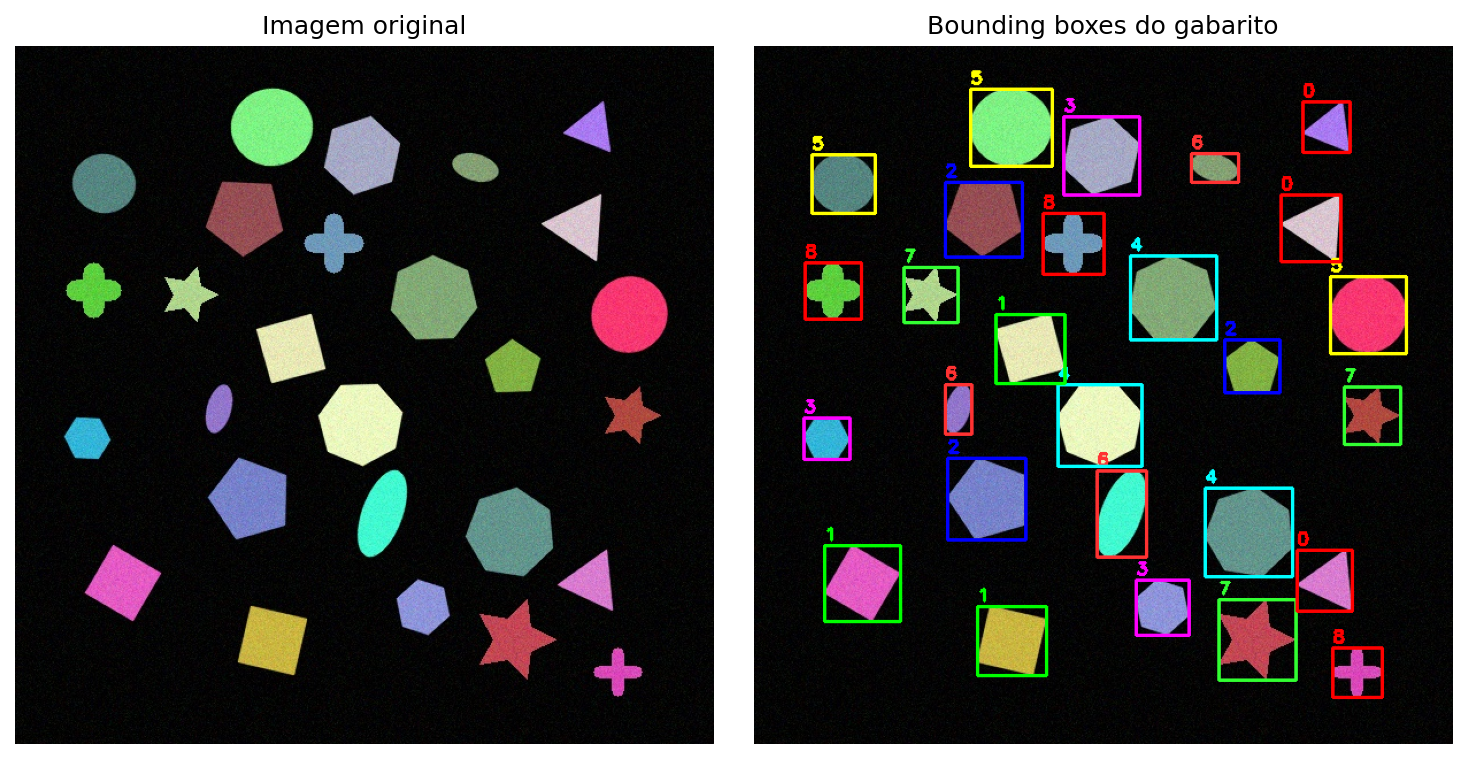

In [35]:
#| label: fig-08-ep12
#| fig-cap: "Simulador EP08_12: Imagem utilizada no EP08_12. À esquerda, a imagem original. À direita, a imagem com as *bounding boxes* do arquivo de gabarito."
#| echo: true
#| output: true

import os
import urllib.request
from morph import mm

def garantir_e_baixar(nome):
    pasta = "dados/EP12"
    caminho = os.path.join(pasta, nome)

    os.makedirs(pasta, exist_ok=True)

    if not os.path.exists(caminho):
        url = (
            "https://raw.githubusercontent.com/"
            "fzampirolli/pdi-vc/master/all/cap08/dados/EP12/"
            + nome
        )
        print(f"Baixando {nome}...")
        urllib.request.urlretrieve(url, caminho)

    return caminho

img_arq = garantir_e_baixar("00000.jpg")
txt_arq = garantir_e_baixar("00000.txt")

img = mm.read(img_arq)
img_bb = mm.showBoundBox(img, txt_arq, fmt="yolo", show=False)

mm.show(
    [img, img_bb],
    titles=[
        "Imagem original",
        "Bounding boxes do gabarito"
    ],
    cols=2,
    figsize=(10,5)
)

In [36]:
#| label: fig-08-sim-ep0812c
#| fig-cap: "Simulador EP08_12: Acurácia de Segmentação em Múltiplos Objetos (IoU)"
#| echo: false
#| output: true

from IPython.display import HTML
HTML('''
<div id="sim-ep0812c" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🧮 Simulador EP08_12: Acurácia de Segmentação em Múltiplos Objetos</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">🟢 acertou se IoU ≥ limiar E tipo correto</span>
  </div>


  <div style="padding:20px;background:white;overflow:auto">

    <p style="font-size:11px;color:#777;margin-bottom:14px;text-align:center;">
      Cada forma tem um <i>boundbox</i> de gabarito (retângulo tracejado, justo em torno da forma) e um <i>boundbox</i> detectado (retângulo sólido, deslocado/ruidoso). Ajuste o ruído, o viés e o limiar de IoU para ver a validação mudar.
    </p>

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:20px;margin-bottom:18px;display:grid;grid-template-columns:1fr 1fr;gap:16px;">
      <div>
        <div style="display:flex;justify-content:space-between;margin-bottom:6px;"><label style="font-size:12px;font-weight:bold;color:#c0392b;">ruído de segmentação (px, jitter máx. por lado)</label><span id="ep0812c_ruido_v" style="font-family:monospace;font-weight:bold;color:#c0392b;">0</span></div>
        <input id="ep0812c_ruido" style="width:100%;accent-color:#c0392b;" max="20" min="0" step="1" type="range" value="0">
      </div>
      <div>
        <div style="display:flex;justify-content:space-between;margin-bottom:6px;"><label style="font-size:12px;font-weight:bold;color:#2980b9;">viés sistemático em x (px)</label><span id="ep0812c_bias_v" style="font-family:monospace;font-weight:bold;color:#2980b9;">0</span></div>
        <input id="ep0812c_bias" style="width:100%;accent-color:#2980b9;" max="20" min="-20" step="1" type="range" value="0">
      </div>
      <div>
        <div style="display:flex;justify-content:space-between;margin-bottom:6px;"><label style="font-size:12px;font-weight:bold;color:#27ae60;">limiar de IoU</label><span id="ep0812c_thr_v" style="font-family:monospace;font-weight:bold;color:#27ae60;">0.50</span></div>
        <input id="ep0812c_thr" style="width:100%;accent-color:#27ae60;" max="0.9" min="0.1" step="0.05" type="range" value="0.5">
      </div>
      <div style="display:flex;align-items:center;gap:8px;">
        <input id="ep0812c_erro" type="checkbox" style="accent-color:#8e44ad;width:16px;height:16px;">
        <label style="font-size:12px;font-weight:bold;color:#8e44ad;">simular erro de classificação (2 objetos com tipo trocado)</label>
      </div>
    </div>

<div id="ep0812c_svg" style="width:100%;max-width:420px;margin:0 auto 16px auto;"></div>

    <table style="width:100%;border-collapse:collapse;font-size:11px;font-family:monospace;margin-bottom:12px;">
      <thead>
        <tr style="background:#f3efe6;">
          <th style="padding:4px;border:1px solid #ddd;">id</th>
          <th style="padding:4px;border:1px solid #ddd;">tipo real</th>
          <th style="padding:4px;border:1px solid #ddd;">tipo detectado</th>
          <th style="padding:4px;border:1px solid #ddd;">IoU</th>
          <th style="padding:4px;border:1px solid #ddd;">≥ limiar</th>
          <th style="padding:4px;border:1px solid #ddd;">acertou</th>
        </tr>
      </thead>
      <tbody id="ep0812c_tbody"></tbody>
    </table>

    <div id="ep0812c_debug" style="background:#e3f2fd;border-radius:8px;padding:10px;border:1px solid #bbdefb;font-family:monospace;font-size:12px;color:#1565c0;text-align:center;"></div>
  </div>
</div>
<script>

function svgNS(tag){
  var SVG_NS = "http" + "://www.w3.org/2000/svg";
  return document.createElementNS(SVG_NS, tag);
}

(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var ruidoEl = root.querySelector('#ep0812c_ruido'), ruidovEl = root.querySelector('#ep0812c_ruido_v');
    var biasEl = root.querySelector('#ep0812c_bias'), biasvEl = root.querySelector('#ep0812c_bias_v');
    var thrEl = root.querySelector('#ep0812c_thr'), thrvEl = root.querySelector('#ep0812c_thr_v');
    var erroEl = root.querySelector('#ep0812c_erro');
    var svgWrap = root.querySelector('#ep0812c_svg');
    var svgEl = svgNS('svg');
    svgEl.setAttribute('viewBox', '0 0 360 340');
    svgEl.setAttribute('style', 'width:100%;display:block;background:#0d0d0d;border-radius:12px;border:1px solid #333;');
    svgWrap.appendChild(svgEl);

    var tbody = root.querySelector('#ep0812c_tbody');
    var dbg = root.querySelector('#ep0812c_debug');

    var TIPOS = ['Circ','Tria','Quad','Cruz','Pent','Hexa','Hept','Estr','Elip'];
    var CORES = ['#a33a5b','#8fe3b0','#c98a7a','#5c4a5e','#3fbf5f','#d9c832','#e08a2b','#5c5470','#4a5a3a'];
    var FATOR = [1.0, 1.3, 0.7, 1.5, 0.9, 1.1, 0.6, 1.4, 0.8]; // sensibilidade individual ao ruído (fixa)
    var ANGS  = [30, 160, 260, 5, 200, 90, 340, 130, 240];      // direção fixa do erro por objeto (graus)
    var SCALE = [0.9, 1.15, 0.8, 1.2, 1.0, 0.95, 1.1, 1.25, 0.85]; // fator de encolhimento/expansão do bbox (fixo)

    var OBJS = [
      {cx:55,  cy:45,  r:22},
      {cx:150, cy:70,  r:24},
      {cx:250, cy:50,  r:22},
      {cx:320, cy:130, r:20},
      {cx:90,  cy:190, r:24},
      {cx:190, cy:220, r:24},
      {cx:275, cy:190, r:24},
      {cx:315, cy:270, r:22},
      {cx:150, cy:150, r:18}
    ];

    function svgShape(tipo, cx, cy, r, cor){
      var s = '';
      if(tipo==='Circ'){
        s = '<circle cx="'+cx+'" cy="'+cy+'" r="'+r+'" fill="'+cor+'"/>';
      } else if(tipo==='Elip'){
        s = '<ellipse cx="'+cx+'" cy="'+cy+'" rx="'+(r*1.1)+'" ry="'+(r*0.65)+'" fill="'+cor+'"/>';
      } else if(tipo==='Quad'){
        s = '<rect x="'+(cx-r*0.8)+'" y="'+(cy-r*0.8)+'" width="'+(r*1.6)+'" height="'+(r*1.6)+'" fill="'+cor+'"/>';
      } else if(tipo==='Cruz'){
        var w = r*0.5, l = r*1.4;
        s = '<g fill="'+cor+'">'+
            '<rect x="'+(cx-w/2)+'" y="'+(cy-l/2)+'" width="'+w+'" height="'+l+'"/>'+
            '<rect x="'+(cx-l/2)+'" y="'+(cy-w/2)+'" width="'+l+'" height="'+w+'"/></g>';
      } else {
        var sides = {Tria:3, Pent:5, Hexa:6, Hept:7}[tipo];
        var isStar = (tipo==='Estr');
        var pts = [];
        if(isStar){
          var spikes=5, outer=r, inner=r*0.45;
          for(var i=0;i<spikes*2;i++){
            var rad = (i%2===0)?outer:inner;
            var ang = Math.PI/spikes*i - Math.PI/2;
            pts.push((cx+rad*Math.cos(ang)).toFixed(1)+','+(cy+rad*Math.sin(ang)).toFixed(1));
          }
        } else {
          for(var i=0;i<sides;i++){
            var ang = 2*Math.PI/sides*i - Math.PI/2;
            pts.push((cx+r*Math.cos(ang)).toFixed(1)+','+(cy+r*Math.sin(ang)).toFixed(1));
          }
        }
        s = '<polygon points="'+pts.join(' ')+'" fill="'+cor+'"/>';
      }
      return s;
    }

    // bbox "verdadeiro": retângulo justo em torno da forma (sem folga artificial)
    function trueBBox(tipo, cx, cy, r){
      var hw = r, hh = r;
      if(tipo==='Elip'){ hw = r*1.1; hh = r*0.65; }
      else if(tipo==='Quad'){ hw = r*0.8; hh = r*0.8; }
      else if(tipo==='Cruz'){ hw = r*0.7; hh = r*0.7; }
      return [cx-hw, cy-hh, cx+hw, cy+hh];
    }

    function iou(a, b){
      var x1 = Math.max(a[0], b[0]), y1 = Math.max(a[1], b[1]);
      var x2 = Math.min(a[2], b[2]), y2 = Math.min(a[3], b[3]);
      var inter = Math.max(0, x2-x1) * Math.max(0, y2-y1);
      var areaA = (a[2]-a[0])*(a[3]-a[1]);
      var areaB = (b[2]-b[0])*(b[3]-b[1]);
      var uni = areaA + areaB - inter;
      return uni > 0 ? inter/uni : 0;
    }

    function render(){
      var ruido = parseInt(ruidoEl.value);
      var bias = parseInt(biasEl.value);
      var thr = parseFloat(thrEl.value);
      var erroAtivo = erroEl.checked;
      ruidovEl.textContent = ruido;
      biasvEl.textContent = bias;
      thrvEl.textContent = thr.toFixed(2);

      var svgContent = '';
      var rows = '';
      var acertos = 0;

      OBJS.forEach(function(o, i){
        var tipoReal = TIPOS[i];
        var cor = CORES[i];

        var gtBox = trueBBox(tipoReal, o.cx, o.cy, o.r);
        svgContent += '<g opacity="0.9">'+svgShape(tipoReal, o.cx, o.cy, o.r, cor)+'</g>';
        svgContent += '<rect x="'+gtBox[0]+'" y="'+gtBox[1]+'" width="'+(gtBox[2]-gtBox[0])+'" height="'+(gtBox[3]-gtBox[1])+'" fill="none" stroke="#aaa" stroke-dasharray="4,3" stroke-width="1.2"/>';

        // bbox detectado: escala fixa individual + jitter (ruído) + viés em x
        var scl = SCALE[i];
        var mag = ruido * FATOR[i];
        var ang = ANGS[i] * Math.PI/180;
        var jx = mag*Math.cos(ang), jy = mag*Math.sin(ang);
        var dw = (gtBox[2]-gtBox[0]) * scl, dh = (gtBox[3]-gtBox[1]) * scl;
        var dcx = o.cx + jx + bias, dcy = o.cy + jy;
        var detBox = [dcx-dw/2, dcy-dh/2, dcx+dw/2, dcy+dh/2];

        var val = iou(gtBox, detBox);
        var passaLimiar = val >= thr;

        var corDet = passaLimiar ? '#27ae60' : '#c0392b';
        svgContent += '<rect x="'+detBox[0]+'" y="'+detBox[1]+'" width="'+(detBox[2]-detBox[0])+'" height="'+(detBox[3]-detBox[1])+'" fill="none" stroke="'+corDet+'" stroke-width="1.6"/>';

        var tipoDetectado = tipoReal;
        if(erroAtivo && (i===1 || i===6)){
          tipoDetectado = TIPOS[(i+2)%TIPOS.length];
        }
        var tipoCorreto = (tipoDetectado === tipoReal);
        var acertou = passaLimiar && tipoCorreto;
        if(acertou) acertos++;

        svgContent += '<text x="'+(o.cx)+'" y="'+(gtBox[1]-6)+'" font-size="9" fill="#ccc" text-anchor="middle" font-family="monospace">'+ (i+1) +'</text>';

        rows += '<tr>'+
          '<td style="padding:4px;border:1px solid #ddd;text-align:center;">'+(i+1)+'</td>'+
          '<td style="padding:4px;border:1px solid #ddd;text-align:center;">'+tipoReal+'</td>'+
          '<td style="padding:4px;border:1px solid #ddd;text-align:center;'+(tipoCorreto?'':'color:#c0392b;font-weight:bold;')+'">'+tipoDetectado+'</td>'+
          '<td style="padding:4px;border:1px solid #ddd;text-align:center;">'+val.toFixed(2)+'</td>'+
          '<td style="padding:4px;border:1px solid #ddd;text-align:center;">'+(passaLimiar?'sim':'não')+'</td>'+
          '<td style="padding:4px;border:1px solid #ddd;text-align:center;'+(acertou?'color:#27ae60;font-weight:bold;':'color:#c0392b;font-weight:bold;')+'">'+(acertou?'✔':'✘')+'</td>'+
          '</tr>';
      });

      svgEl.innerHTML = svgContent;
      tbody.innerHTML = rows;

      var acc = (acertos/OBJS.length*100).toFixed(1);
      dbg.textContent = 'Objetos validados: '+acertos+' / '+OBJS.length+'  →  Acurácia = '+acc+'%';
    }

    ruidoEl.addEventListener('input', render);
    biasEl.addEventListener('input', render);
    thrEl.addEventListener('input', render);
    erroEl.addEventListener('change', render);
    render();
  }
  function tryInit(){
    var root = document.getElementById('sim-ep0812c');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

id,tipo real,tipo detectado,IoU,≥ limiar,acertou


In [37]:
%%writefile EP08_12.py
# Código Python

Writing EP08_12.py


In [38]:
TestSuite("EP08_12.py").run()